# Bibliotecas Usadas

In [49]:
# Bibliotecas usadas:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
from io import StringIO
import seaborn as sns
from scipy.stats import norm
from itertools import product
from scipy import stats
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# PARTE 1

---



## A ) Histogramas e Dataset

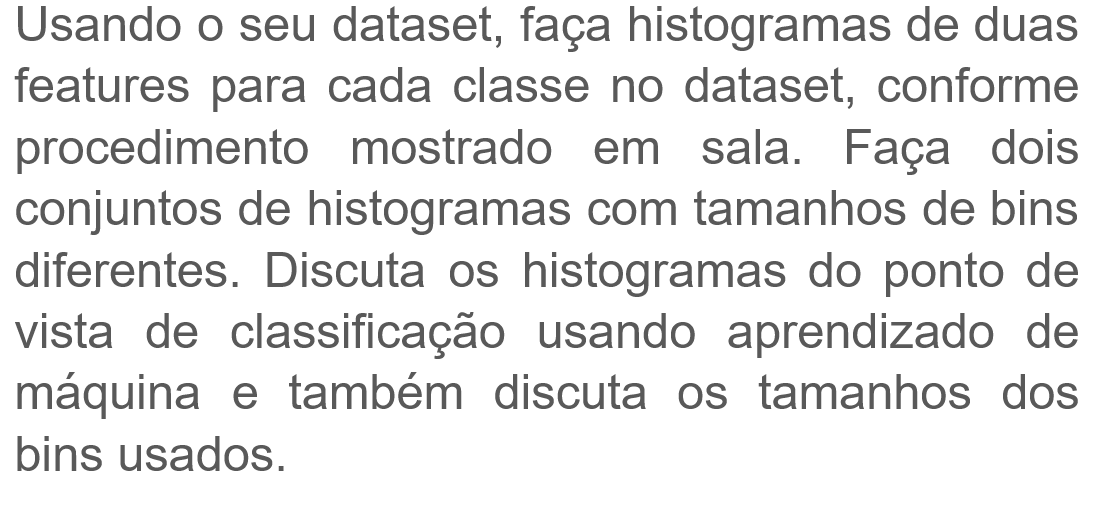

### Detalhes do Dataset:
O dataset contém características de três tipos diferentes de trigo, cada variedade de trigo teve 70 coletas de dados para medições.

As varidades de trigo (não são espécies de trigo) são as seguintes:

- Canadian: Trigo originário e típico do Canadá (geralmente da espécie Triticum aestivum). É muito reconhecido mundialmente pela sua alta qualidade e teor de proteínas.

- Kama: Variedade frequentemente utilizada em bancos de dados agronômicos e de classificação para representar um tipo morfológico específico de grão de trigo.

- Rosa: Outra variedade clássica de trigo frequentemente categorizada junto com Kama e Canadian em estudos botânicos e experimentos de classificação de sementes.

Features:

As features são sete características geométricas presentes nessas variedades de grão de trigo. Elas são as seguintes:

- Área (A): tamanho da superficie dos grãos.
- Perímetro (P): Se trata do comprimento da borda do grão
- Compacidade: É a medida do quão compacto é o grão.
- Comprimento do grão: O tamanho do grão em seu eixo maior.
- Largura do grão: É a espessura do grão no seu eixo menor.
- Coeficiente de Asssimetria: Mede o quão simétrico é o grão.
- Comprimento da Ranhura do Grão: Mede o comprimento da ranhura dos grãos.

A fórmula de cálculo da features é:

Área:
$$
A = \sum \text{quantidade de pixels pertencentes ao grão.}
$$

Compacidade:
$$
C = \frac{4 \pi A}{P^2}
$$

Perímetro:
$$
P = \sum \text{comprimento da borda}
$$

Comprimento do Grão:
$$
L = \max(d)
$$

Largura do Grão:
$$
W = \min(d)
$$

Coeficiente de Assimetria:
$$
\text{Assimetria} =
\frac{1}{n}
\sum
\left(
\frac{x_i - \mu}{\sigma}
\right)^3
$$

Comprimento da Ranhura:
$$
G = \text{comprimento do sulco central}
$$



$ $

Classes:

As classes foram divididas em $1$, $2$, $3$. Elas estão na seguinte ordem: $[Kama, Rosa, Canadian ]$

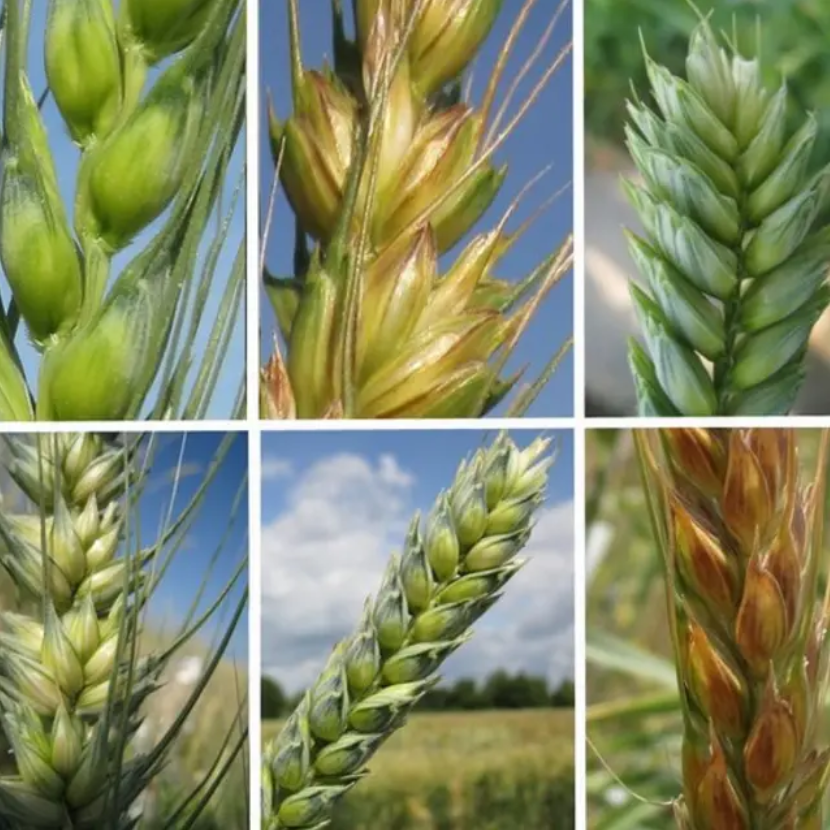

Imagem ilustrativa dos tipos diferentes de Trigo.

### Dados

In [12]:
dataset_seeds = """
ID,area,perimeter,compactness,lengthOfKernel,widthOfKernel,asymmetryCoefficient,lengthOfKernelGroove,seedType
1,15.26,14.84,0.871,5.763,3.312,2.221,5.22,1
2,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
3,14.29,14.09,0.905,5.291,3.337,2.699,4.825,1
4,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
5,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
6,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,1
7,14.69,14.49,0.8799,5.563,3.259,3.586,5.219,1
8,14.11,14.1,0.8911,5.42,3.302,2.7,5,1
9,16.63,15.46,0.8747,6.053,3.465,2.04,5.877,1
10,16.44,15.25,0.888,5.884,3.505,1.969,5.533,1
11,15.26,14.85,0.8696,5.714,3.242,4.543,5.314,1
12,14.03,14.16,0.8796,5.438,3.201,1.717,5.001,1
13,13.89,14.02,0.888,5.439,3.199,3.986,4.738,1
14,13.78,14.06,0.8759,5.479,3.156,3.136,4.872,1
15,13.74,14.05,0.8744,5.482,3.114,2.932,4.825,1
16,14.59,14.28,0.8993,5.351,3.333,4.185,4.781,1
17,13.99,13.83,0.9183,5.119,3.383,5.234,4.781,1
18,15.69,14.75,0.9058,5.527,3.514,1.599,5.046,1
19,14.7,14.21,0.9153,5.205,3.466,1.767,4.649,1
20,12.72,13.57,0.8686,5.226,3.049,4.102,4.914,1
21,14.16,14.4,0.8584,5.658,3.129,3.072,5.176,1
22,14.11,14.26,0.8722,5.52,3.168,2.688,5.219,1
23,15.88,14.9,0.8988,5.618,3.507,0.7651,5.091,1
24,12.08,13.23,0.8664,5.099,2.936,1.415,4.961,1
25,15.01,14.76,0.8657,5.789,3.245,1.791,5.001,1
26,16.19,15.16,0.8849,5.833,3.421,0.903,5.307,1
27,13.02,13.76,0.8641,5.395,3.026,3.373,4.825,1
28,12.74,13.67,0.8564,5.395,2.956,2.504,4.869,1
29,14.11,14.18,0.882,5.541,3.221,2.754,5.038,1
30,13.45,14.02,0.8604,5.516,3.065,3.531,5.097,1
31,13.16,13.82,0.8662,5.454,2.975,0.8551,5.056,1
32,15.49,14.94,0.8724,5.757,3.371,3.412,5.228,1
33,14.09,14.41,0.8529,5.717,3.186,3.92,5.299,1
34,13.94,14.17,0.8728,5.585,3.15,2.124,5.012,1
35,15.05,14.68,0.8779,5.712,3.328,2.129,5.36,1
36,16.12,15,0.9,5.709,3.485,2.27,5.443,1
37,16.2,15.27,0.8734,5.826,3.464,2.823,5.527,1
38,17.08,15.38,0.9079,5.832,3.683,2.956,5.484,1
39,14.8,14.52,0.8823,5.656,3.288,3.112,5.309,1
40,14.28,14.17,0.8944,5.397,3.298,6.685,5.001,1
41,13.54,13.85,0.8871,5.348,3.156,2.587,5.178,1
42,13.5,13.85,0.8852,5.351,3.158,2.249,5.176,1
43,13.16,13.55,0.9009,5.138,3.201,2.461,4.783,1
44,15.5,14.86,0.882,5.877,3.396,4.711,5.528,1
45,15.11,14.54,0.8986,5.579,3.462,3.128,5.18,1
46,13.8,14.04,0.8794,5.376,3.155,1.56,4.961,1
47,15.36,14.76,0.8861,5.701,3.393,1.367,5.132,1
48,14.99,14.56,0.8883,5.57,3.377,2.958,5.175,1
49,14.79,14.52,0.8819,5.545,3.291,2.704,5.111,1
50,14.86,14.67,0.8676,5.678,3.258,2.129,5.351,1
51,14.43,14.4,0.8751,5.585,3.272,3.975,5.144,1
52,15.78,14.91,0.8923,5.674,3.434,5.593,5.136,1
53,14.49,14.61,0.8538,5.715,3.113,4.116,5.396,1
54,14.33,14.28,0.8831,5.504,3.199,3.328,5.224,1
55,14.52,14.6,0.8557,5.741,3.113,1.481,5.487,1
56,15.03,14.77,0.8658,5.702,3.212,1.933,5.439,1
57,14.46,14.35,0.8818,5.388,3.377,2.802,5.044,1
58,14.92,14.43,0.9006,5.384,3.412,1.142,5.088,1
59,15.38,14.77,0.8857,5.662,3.419,1.999,5.222,1
60,12.11,13.47,0.8392,5.159,3.032,1.502,4.519,1
61,11.42,12.86,0.8683,5.008,2.85,2.7,4.607,1
62,11.23,12.63,0.884,4.902,2.879,2.269,4.703,1
63,12.36,13.19,0.8923,5.076,3.042,3.22,4.605,1
64,13.22,13.84,0.868,5.395,3.07,4.157,5.088,1
65,12.78,13.57,0.8716,5.262,3.026,1.176,4.782,1
66,12.88,13.5,0.8879,5.139,3.119,2.352,4.607,1
67,14.34,14.37,0.8726,5.63,3.19,1.313,5.15,1
68,14.01,14.29,0.8625,5.609,3.158,2.217,5.132,1
69,14.37,14.39,0.8726,5.569,3.153,1.464,5.3,1
70,12.73,13.75,0.8458,5.412,2.882,3.533,5.067,1
71,17.63,15.98,0.8673,6.191,3.561,4.076,6.06,2
72,16.84,15.67,0.8623,5.998,3.484,4.675,5.877,2
73,17.26,15.73,0.8763,5.978,3.594,4.539,5.791,2
74,19.11,16.26,0.9081,6.154,3.93,2.936,6.079,2
75,16.82,15.51,0.8786,6.017,3.486,4.004,5.841,2
76,16.77,15.62,0.8638,5.927,3.438,4.92,5.795,2
77,17.32,15.91,0.8599,6.064,3.403,3.824,5.922,2
78,20.71,17.23,0.8763,6.579,3.814,4.451,6.451,2
79,18.94,16.49,0.875,6.445,3.639,5.064,6.362,2
80,17.12,15.55,0.8892,5.85,3.566,2.858,5.746,2
81,16.53,15.34,0.8823,5.875,3.467,5.532,5.88,2
82,18.72,16.19,0.8977,6.006,3.857,5.324,5.879,2
83,20.2,16.89,0.8894,6.285,3.864,5.173,6.187,2
84,19.57,16.74,0.8779,6.384,3.772,1.472,6.273,2
85,19.51,16.71,0.878,6.366,3.801,2.962,6.185,2
86,18.27,16.09,0.887,6.173,3.651,2.443,6.197,2
87,18.88,16.26,0.8969,6.084,3.764,1.649,6.109,2
88,18.98,16.66,0.859,6.549,3.67,3.691,6.498,2
89,21.18,17.21,0.8989,6.573,4.033,5.78,6.231,2
90,20.88,17.05,0.9031,6.45,4.032,5.016,6.321,2
91,20.1,16.99,0.8746,6.581,3.785,1.955,6.449,2
92,18.76,16.2,0.8984,6.172,3.796,3.12,6.053,2
93,18.81,16.29,0.8906,6.272,3.693,3.237,6.053,2
94,18.59,16.05,0.9066,6.037,3.86,6.001,5.877,2
95,18.36,16.52,0.8452,6.666,3.485,4.933,6.448,2
96,16.87,15.65,0.8648,6.139,3.463,3.696,5.967,2
97,19.31,16.59,0.8815,6.341,3.81,3.477,6.238,2
98,18.98,16.57,0.8687,6.449,3.552,2.144,6.453,2
99,18.17,16.26,0.8637,6.271,3.512,2.853,6.273,2
100,18.72,16.34,0.881,6.219,3.684,2.188,6.097,2
101,16.41,15.25,0.8866,5.718,3.525,4.217,5.618,2
102,17.99,15.86,0.8992,5.89,3.694,2.068,5.837,2
103,19.46,16.5,0.8985,6.113,3.892,4.308,6.009,2
104,19.18,16.63,0.8717,6.369,3.681,3.357,6.229,2
105,18.95,16.42,0.8829,6.248,3.755,3.368,6.148,2
106,18.83,16.29,0.8917,6.037,3.786,2.553,5.879,2
107,18.85,16.17,0.9056,6.152,3.806,2.843,6.2,2
108,17.63,15.86,0.88,6.033,3.573,3.747,5.929,2
109,19.94,16.92,0.8752,6.675,3.763,3.252,6.55,2
110,18.55,16.22,0.8865,6.153,3.674,1.738,5.894,2
111,18.45,16.12,0.8921,6.107,3.769,2.235,5.794,2
112,19.38,16.72,0.8716,6.303,3.791,3.678,5.965,2
113,19.13,16.31,0.9035,6.183,3.902,2.109,5.924,2
114,19.14,16.61,0.8722,6.259,3.737,6.682,6.053,2
115,20.97,17.25,0.8859,6.563,3.991,4.677,6.316,2
116,19.06,16.45,0.8854,6.416,3.719,2.248,6.163,2
117,18.96,16.2,0.9077,6.051,3.897,4.334,5.75,2
118,19.15,16.45,0.889,6.245,3.815,3.084,6.185,2
119,18.89,16.23,0.9008,6.227,3.769,3.639,5.966,2
120,20.03,16.9,0.8811,6.493,3.857,3.063,6.32,2
121,20.24,16.91,0.8897,6.315,3.962,5.901,6.188,2
122,18.14,16.12,0.8772,6.059,3.563,3.619,6.011,2
123,16.17,15.38,0.8588,5.762,3.387,4.286,5.703,2
124,18.43,15.97,0.9077,5.98,3.771,2.984,5.905,2
125,15.99,14.89,0.9064,5.363,3.582,3.336,5.144,2
126,18.75,16.18,0.8999,6.111,3.869,4.188,5.992,2
127,18.65,16.41,0.8698,6.285,3.594,4.391,6.102,2
128,17.98,15.85,0.8993,5.979,3.687,2.257,5.919,2
129,20.16,17.03,0.8735,6.513,3.773,1.91,6.185,2
130,17.55,15.66,0.8991,5.791,3.69,5.366,5.661,2
131,18.3,15.89,0.9108,5.979,3.755,2.837,5.962,2
132,18.94,16.32,0.8942,6.144,3.825,2.908,5.949,2
133,15.38,14.9,0.8706,5.884,3.268,4.462,5.795,2
134,16.16,15.33,0.8644,5.845,3.395,4.266,5.795,2
135,15.56,14.89,0.8823,5.776,3.408,4.972,5.847,2
136,15.38,14.66,0.899,5.477,3.465,3.6,5.439,2
137,17.36,15.76,0.8785,6.145,3.574,3.526,5.971,2
138,15.57,15.15,0.8527,5.92,3.231,2.64,5.879,2
139,15.6,15.11,0.858,5.832,3.286,2.725,5.752,2
140,16.23,15.18,0.885,5.872,3.472,3.769,5.922,2
141,13.07,13.92,0.848,5.472,2.994,5.304,5.395,3
142,13.32,13.94,0.8613,5.541,3.073,7.035,5.44,3
143,13.34,13.95,0.862,5.389,3.074,5.995,5.307,3
144,12.22,13.32,0.8652,5.224,2.967,5.469,5.221,3
145,11.82,13.4,0.8274,5.314,2.777,4.471,5.178,3
146,11.21,13.13,0.8167,5.279,2.687,6.169,5.275,3
147,11.43,13.13,0.8335,5.176,2.719,2.221,5.132,3
148,12.49,13.46,0.8658,5.267,2.967,4.421,5.002,3
149,12.7,13.71,0.8491,5.386,2.911,3.26,5.316,3
150,10.79,12.93,0.8107,5.317,2.648,5.462,5.194,3
151,11.83,13.23,0.8496,5.263,2.84,5.195,5.307,3
152,12.01,13.52,0.8249,5.405,2.776,6.992,5.27,3
153,12.26,13.6,0.8333,5.408,2.833,4.756,5.36,3
154,11.18,13.04,0.8266,5.22,2.693,3.332,5.001,3
155,11.36,13.05,0.8382,5.175,2.755,4.048,5.263,3
156,11.19,13.05,0.8253,5.25,2.675,5.813,5.219,3
157,11.34,12.87,0.8596,5.053,2.849,3.347,5.003,3
158,12.13,13.73,0.8081,5.394,2.745,4.825,5.22,3
159,11.75,13.52,0.8082,5.444,2.678,4.378,5.31,3
160,11.49,13.22,0.8263,5.304,2.695,5.388,5.31,3
161,12.54,13.67,0.8425,5.451,2.879,3.082,5.491,3
162,12.02,13.33,0.8503,5.35,2.81,4.271,5.308,3
163,12.05,13.41,0.8416,5.267,2.847,4.988,5.046,3
164,12.55,13.57,0.8558,5.333,2.968,4.419,5.176,3
165,11.14,12.79,0.8558,5.011,2.794,6.388,5.049,3
166,12.1,13.15,0.8793,5.105,2.941,2.201,5.056,3
167,12.44,13.59,0.8462,5.319,2.897,4.924,5.27,3
168,12.15,13.45,0.8443,5.417,2.837,3.638,5.338,3
169,11.35,13.12,0.8291,5.176,2.668,4.337,5.132,3
170,11.24,13,0.8359,5.09,2.715,3.521,5.088,3
171,11.02,13,0.8189,5.325,2.701,6.735,5.163,3
172,11.55,13.1,0.8455,5.167,2.845,6.715,4.956,3
173,11.27,12.97,0.8419,5.088,2.763,4.309,5,3
174,11.4,13.08,0.8375,5.136,2.763,5.588,5.089,3
175,10.83,12.96,0.8099,5.278,2.641,5.182,5.185,3
176,10.8,12.57,0.859,4.981,2.821,4.773,5.063,3
177,11.26,13.01,0.8355,5.186,2.71,5.335,5.092,3
178,10.74,12.73,0.8329,5.145,2.642,4.702,4.963,3
179,11.48,13.05,0.8473,5.18,2.758,5.876,5.002,3
180,12.21,13.47,0.8453,5.357,2.893,1.661,5.178,3
181,11.41,12.95,0.856,5.09,2.775,4.957,4.825,3
182,12.46,13.41,0.8706,5.236,3.017,4.987,5.147,3
183,12.19,13.36,0.8579,5.24,2.909,4.857,5.158,3
184,11.65,13.07,0.8575,5.108,2.85,5.209,5.135,3
185,12.89,13.77,0.8541,5.495,3.026,6.185,5.316,3
186,11.56,13.31,0.8198,5.363,2.683,4.062,5.182,3
187,11.81,13.45,0.8198,5.413,2.716,4.898,5.352,3
188,10.91,12.8,0.8372,5.088,2.675,4.179,4.956,3
189,11.23,12.82,0.8594,5.089,2.821,7.524,4.957,3
190,10.59,12.41,0.8648,4.899,2.787,4.975,4.794,3
191,10.93,12.8,0.839,5.046,2.717,5.398,5.045,3
192,11.27,12.86,0.8563,5.091,2.804,3.985,5.001,3
193,11.87,13.02,0.8795,5.132,2.953,3.597,5.132,3
194,10.82,12.83,0.8256,5.18,2.63,4.853,5.089,3
195,12.11,13.27,0.8639,5.236,2.975,4.132,5.012,3
196,12.8,13.47,0.886,5.16,3.126,4.873,4.914,3
197,12.79,13.53,0.8786,5.224,3.054,5.483,4.958,3
198,13.37,13.78,0.8849,5.32,3.128,4.67,5.091,3
199,12.62,13.67,0.8481,5.41,2.911,3.306,5.231,3
200,12.76,13.38,0.8964,5.073,3.155,2.828,4.83,3
201,12.38,13.44,0.8609,5.219,2.989,5.472,5.045,3
202,12.67,13.32,0.8977,4.984,3.135,2.3,4.745,3
203,11.18,12.72,0.868,5.009,2.81,4.051,4.828,3
204,12.7,13.41,0.8874,5.183,3.091,8.456,5,3
205,12.37,13.47,0.8567,5.204,2.96,3.919,5.001,3
206,12.19,13.2,0.8783,5.137,2.981,3.631,4.87,3
207,11.23,12.88,0.8511,5.14,2.795,4.325,5.003,3
208,13.2,13.66,0.8883,5.236,3.232,8.315,5.056,3
209,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3
210,12.3,13.34,0.8684,5.243,2.974,5.637,5.063,3
"""

In [14]:
df = pd.read_csv(StringIO(dataset_seeds))

df.describe()

,ID,area,perimeter,compactness,lengthOfKernel,widthOfKernel,asymmetryCoefficient,lengthOfKernelGroove,seedType
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,105.500000,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,60.765944,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,1.000000,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,53.250000,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,105.500000,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,157.750000,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,210.000000,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


### Histogramas das duas features para cada classe do Dataset

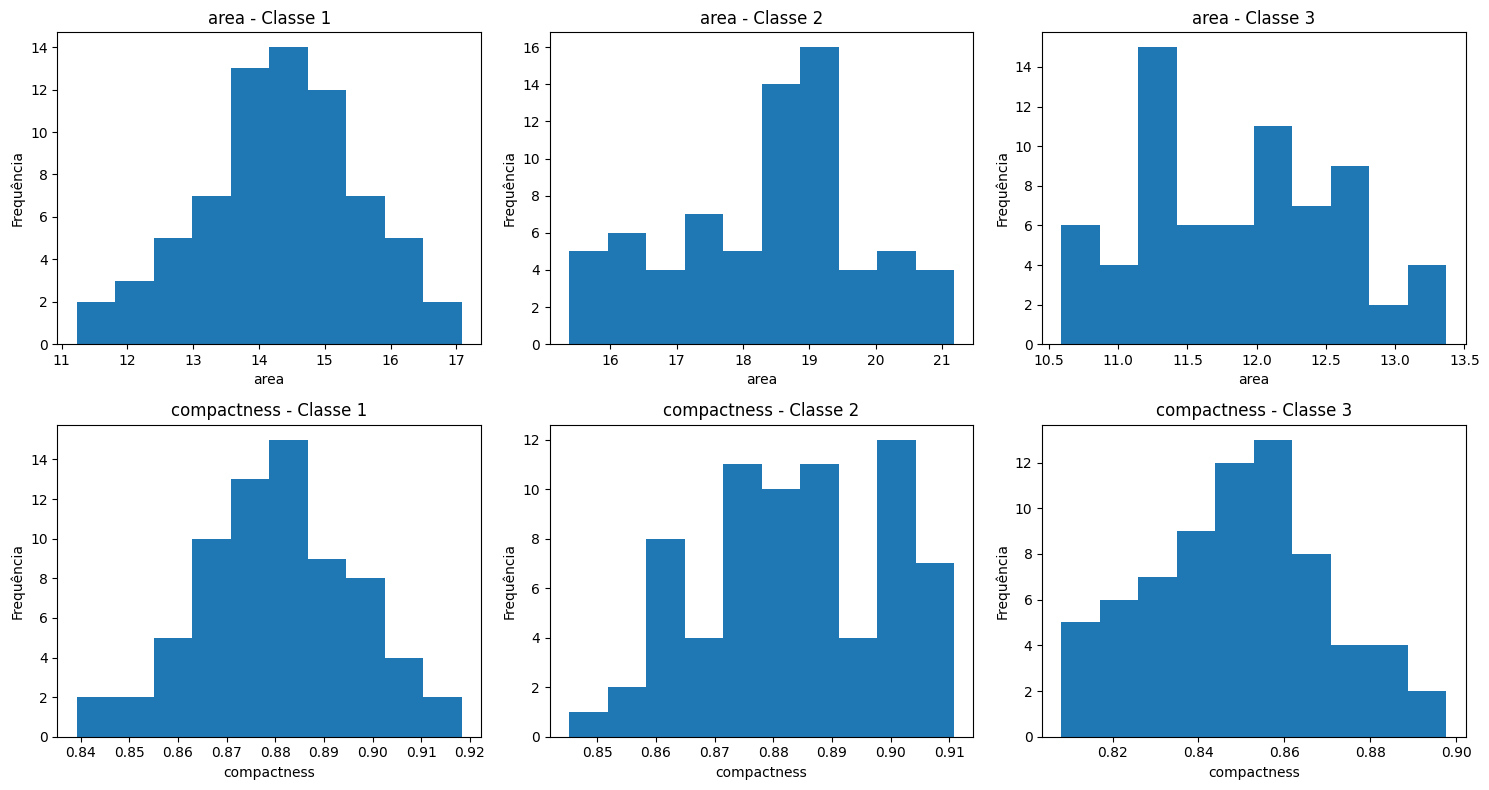

In [ ]:
# Características (Features) escolhidas
features = ["area", "compactness"]

# As três Classes de Trigo do Dataset(Kama, Rosa, Canadian)
classes = [1, 2, 3]

# Histogramas com caixas (bins) de tamanho 10
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for i, feature in enumerate(features):
    for j, classe in enumerate(classes):
        dados = df[df["seedType"] == classe][feature]

        axs[i, j].hist(dados, bins=10)
        axs[i, j].set_title(f"{feature} - Classe {classe}")
        axs[i, j].set_xlabel(feature)
        axs[i, j].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

### Histogramas das duas features para cada classe do Dataset com Caixas (bins) de valor diferente

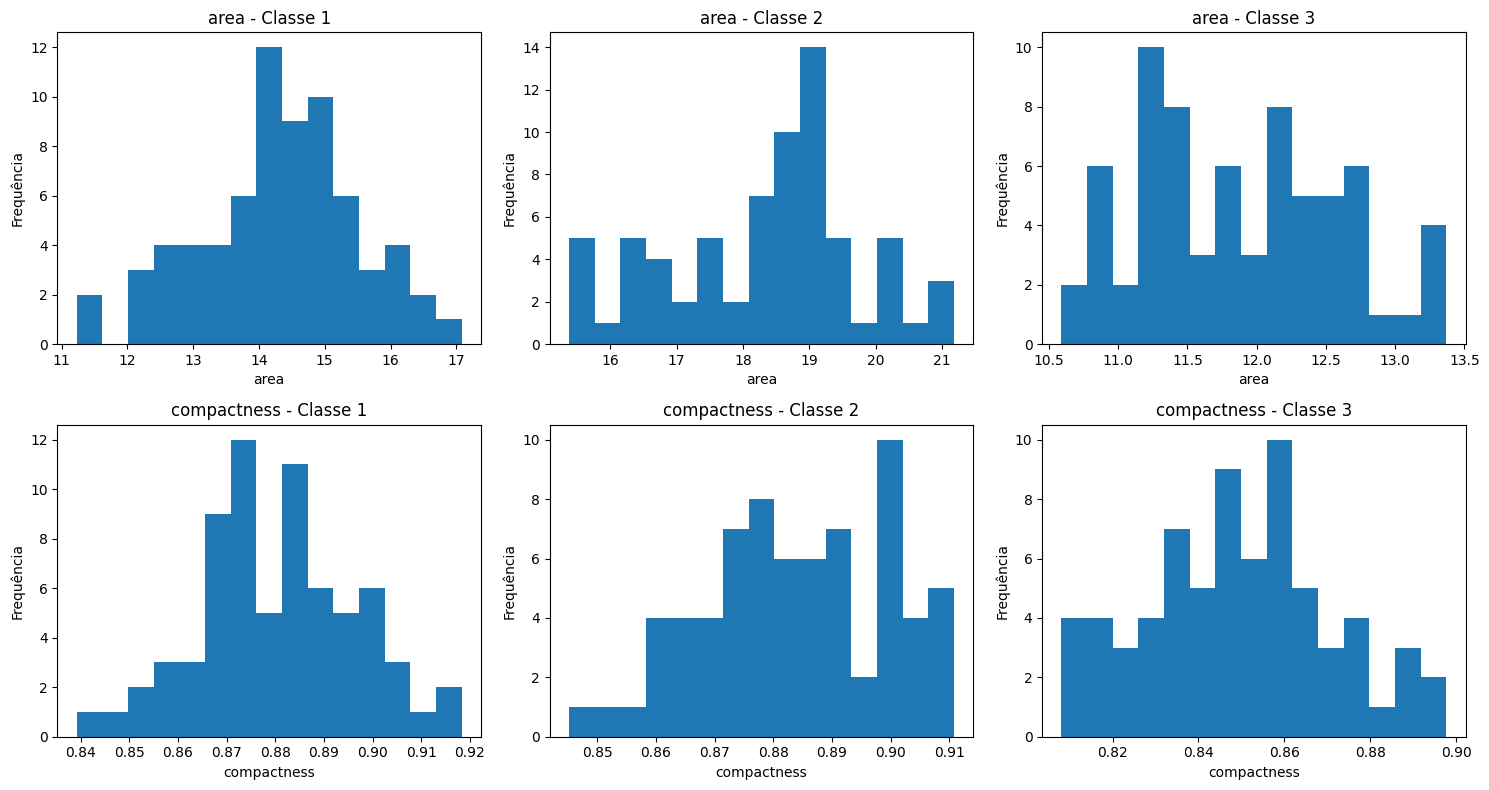

In [ ]:
# Características (Features) escolhidas
features = ["area", "compactness"]

# As três Classes de Trigo do Dataset(Kama, Rosa, Canadian)
classes = [1, 2, 3]

# Histogramas com caixas (bins) de tamanho 15
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for i, feature in enumerate(features):
    for j, classe in enumerate(classes):
        dados = df[df["seedType"] == classe][feature]

        axs[i, j].hist(dados, bins=15)
        axs[i, j].set_title(f"{feature} - Classe {classe}")
        axs[i, j].set_xlabel(feature)
        axs[i, j].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

### Análise

Foram analisadas as features **Area** e **Compactness** para as três classes presentes no Seeds Dataset. Os histogramas foram gerados utilizando dois tamanhos de bins diferentes $(10 e 15)$, permitindo avaliar como a discretização dos dados influencia a visualização das distribuições.

**Análise da Feature Area**

Observa-se que a feature **Area** apresenta boa capacidade de separação entre as classes. A Classe $2$ possui valores de área significativamente maiores, concentrando-se aproximadamente entre $15.5$ e $21$. Já a Classe $3$ apresenta os menores valores, concentrando-se entre $10.5$ e $13.5$. A Classe $1$ ocupa uma região intermediária, entre aproximadamente $11$ e $17$.

Do ponto de vista de classificação, essa característica é bastante relevante, pois existe pouca sobreposição entre as distribuições das Classes $2$ e $3$. Dessa forma, algoritmos de aprendizado de máquina podem utilizar essa feature para distinguir as classes com relativa facilidade. Entretanto, existe alguma sobreposição entre as Classes $1$ e $2$, o que pode gerar ambiguidades para determinadas observações.

**Análise da Feature Compactness**

A feature **Compactness** apresenta distribuições muito mais próximas entre as três classes. Os valores concentram-se aproximadamente entre $0.81$ e $0.92$ para todas as classes, gerando uma forte sobreposição dos histogramas.

Sob a perspectiva de classificação, essa feature isoladamente possui menor poder discriminativo quando comparada à Area. Embora existam pequenas diferenças entre as médias das classes, a grande região de interseção dificulta a separação direta dos grupos. Ainda assim, a feature pode contribuir para a classificação quando utilizada em conjunto com outras características do dataset.

**Influência do Número de Bins**

Nos histogramas com **10 bins**, as distribuições aparecem mais suavizadas, facilitando a identificação do comportamento geral dos dados e das tendências centrais de cada classe. Entretanto, detalhes locais podem ser ocultados devido à menor resolução.

Já nos histogramas com **15 bins**, a distribuição torna-se mais detalhada, permitindo observar melhor pequenas variações e concentrações de frequência. Por outro lado, o aumento do número de bins pode introduzir maior variabilidade visual e destacar flutuações decorrentes do tamanho limitado da amostra.

De forma geral, ambos os tamanhos de bins permitem observar os padrões principais do dataset. Os histogramas com 10 bins fornecem uma visão mais estável das distribuições, enquanto os histogramas com $15$ bins oferecem uma representação mais detalhada dos dados.

## B ) Z-Score e o Tema



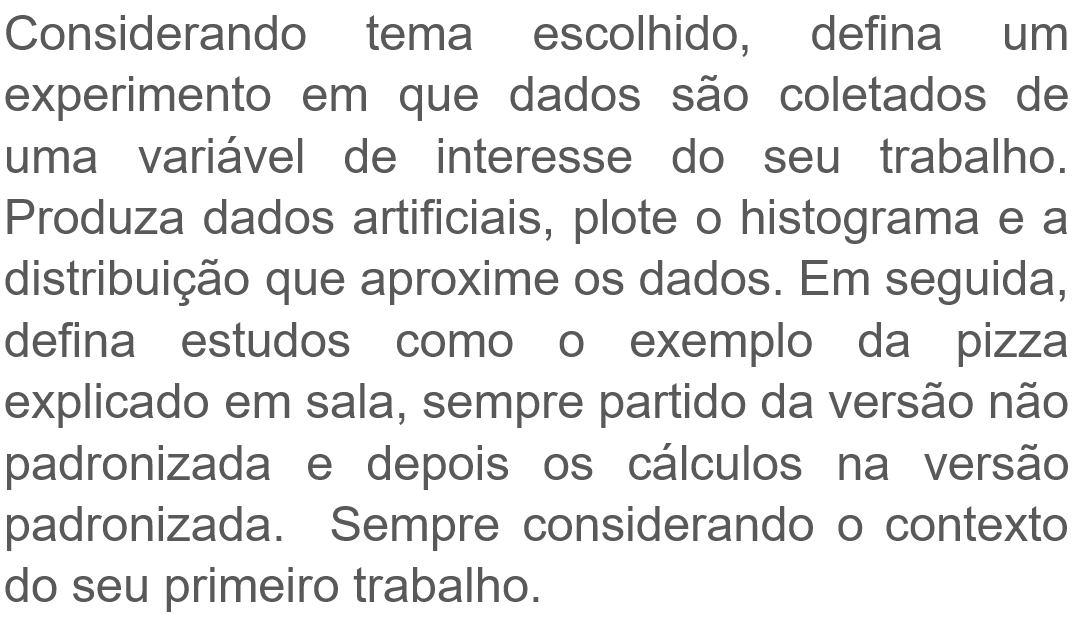

#### O que é a Pontuação Z

Mais conhecida como **Z-Score**, ela oferece uma maneira padronizada de entender onde qualquer ponto de dados se situa em relação à sua distribuição.

A Pontuação Z é uma medida estatística que quantifica a distância entre um ponto de dados e a média de um conjunto de dados. É expresso em termos de desvios padrão. Indica quantos desvios padrão um ponto de dados está da média da distribuição.

Se o valor *Z* for $0$, isso indica que a pontuação do ponto de dados é idêntica à pontuação média. Um valor Z de $1.0$ indicaria um valor que está a um desvio padrão da média. Os valores Z podem ser positivos ou negativos, sendo que um valor positivo indica que a pontuação está acima da média e um valor negativo indica que está abaixo da média.

#### Fórmula e Interpretação

$$Z=\frac{X-\mu }{\sigma }$$

onde:
- $X$ é a sua pontuação bruta
- μ (mu) é a média da população
- σ (sigma) é o desvio padrão da população.

Os escores Z permitem comparar diretamente pontos de dados de diferentes distribuições, independentemente de suas unidades ou escalas originais.

A interpretação do Z-score segue regras direcionais consistentes, independentemente dos seus dados originais. Pontuações z positivas indicam valores acima da média, enquanto pontuações z negativas mostram valores abaixo da média. Um z-score de 0 quer dizer que o seu ponto de dados é igual à média.

Para dados normalmente distribuídos, você pode usar algumas dicas extras de interpretação: valores com pontuações z além de ±2 são incomuns (acontecem em cerca de 5% dos casos), enquanto pontuações z além de ±3 são raras (menos de 1% de probabilidade). Você pode encontrar os percentis exatos para distribuições normais usando tabelas z, que mostram qual porcentagem das observações fica abaixo de qualquer pontuação z dada.

Para dados não normais, os escores z ainda mostram a posição relativa e ajudam a identificar possíveis valores atípicos, mas as porcentagens específicas não se aplicam.

### Experimento relacionado a Váriavel de Interesse

O experimento pode ser um estudo sobre como compactação adequada garante que a semente tenha o contato ideal com a terra para absorver a umidade e os nutrientes necessários para germinar rapidamente.

A váriavel de interesse (Característica/Feature) escolhida é a da **Compacidade da semente**, tendo em vista que essa ***feature*** terá distribuição usando casas decimais, o que pode complicar a aplicação de gráficos relativamente visíveis.



### Código

In [72]:
# Valores de Feature tirados do Dataset
mean_compact = df["compactness"].mean()
std_compact = df["compactness"].std()

print("Média da Compacidade (Compactness):", mean_compact)
print("\nDesvio padrão da Compacidade (Compactness):", std_compact)

Média da Compacidade (Compactness): 0.8709985714285714

Desvio padrão da Compacidade (Compactness): 0.0236294165838465


In [81]:
# Geração dos Valores Artificiais
artificial_data = np.random.normal(mean_compact, std_compact, 1000)
# Definição do Limiar
threshold = 0.85

### Histograma

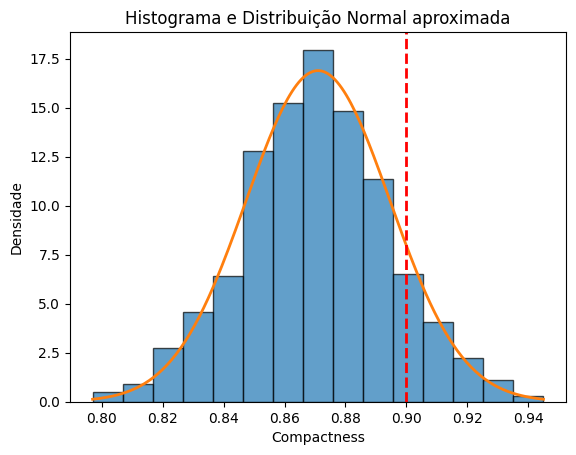

In [85]:
# histograma normalizado
plt.hist(artificial_data, bins=15, density=True, edgecolor='black', alpha=0.7)

# curva normal aproximada
x = np.linspace(artificial_data.min(), artificial_data.max(), 200)
y = norm.pdf(x, mean_compact, std_compact)

plt.plot(x, y, linewidth=2)

# Threshold
plt.axvline(threshold, linestyle="--", linewidth=2, label=f"Threshold = {threshold}", color ="red")

plt.xlabel("Compactness")
plt.ylabel("Densidade")
plt.title("Histograma e Distribuição Normal aproximada")
plt.show()

Estudo 1:

In [88]:
# Não Padronizado
prob_non_standard = 1 - norm.cdf(threshold, loc=mean_compact, scale=std_compact)

print("Evento: P(X > 0.90)\n")

print("Abordagem Não Padronizada:")
print(f"P(X > {threshold}) = 1 - P(X ≤ {threshold})")
print(f"Resultado = {prob_non_standard:.6f}\n")

# Padronizado
z_score = (threshold - mean_compact) / std_compact
prob_standard = 1 - norm.cdf(z_score)

print("Abordagem Padronizada:")
print(f"Z-Score = {z_score:.4f}")
print(f"P(Z-Score > {z_score:.4f})")
print(f"Resultado = {prob_standard:.6f}")

Evento: P(X > 0.90)

Abordagem Não Padronizada:
P(X > 0.9) = 1 - P(X ≤ 0.9)
Resultado = 0.109847

Abordagem Padronizada:
Z-Score = 1.2273
P(Z-Score > 1.2273)
Resultado = 0.109847


### Análise 1
A probabilidade de uma semente apresentar **Compactness superior a $0.90$** foi de aproximadamente **$10.98\%$**. Isso indica que valores acima desse limiar são relativamente incomuns na distribuição considerada, ocorrendo em cerca de 11 a cada 100 sementes.

Na abordagem padronizada, foi obtido um **Z-Score de $1.2273$**, o que significa que o valor 0,90 está aproximadamente **$1.23$ desvios padrão acima da média** da população.

Observa-se que tanto a abordagem não padronizada quanto a padronizada produziram exatamente a mesma probabilidade ($**0.109847**$), confirmando que a padronização apenas transforma a variável para a escala da Normal padrão sem alterar o resultado probabilístico. Dessa forma, a utilização do Z-Score permite consultar tabelas da Normal padrão e obter a mesma probabilidade encontrada diretamente pela distribuição original.

Estudo 2:

In [90]:
threshold = 0.80
prob_non_standard = norm.cdf( threshold, loc=mean_compact, scale=std_compact)
print("Evento: P(X < 0.80)\n")

# Não Padronizada
print("Abordagem Não Padronizada:")
print(f"P(X < {threshold})")
print(f"Resultado = {prob_non_standard:.6f}\n")

# Padronizada
z_score = (threshold - mean_compact) / std_compact
prob_standard = norm.cdf(z_score)

print("Abordagem Padronizada:")
print(f"Z-Score = {z_score:.4f}")
print(f"P(Z-Score < {z_score:.4f})")
print(f"Resultado = {prob_standard:.6f}")

Evento: P(X < 0.80)

Abordagem Não Padronizada:
P(X < 0.8)
Resultado = 0.001329

Abordagem Padronizada:
Z-Score = -3.0047
P(Z < -3.0047)
Resultado = 0.001329


### Análise 2

A probabilidade de uma semente apresentar **Compactness inferior a $0.80$** foi de aproximadamente **$0.13%$**, indicando que esse é um evento bastante raro dentro da distribuição considerada.

O valor padronizado obtido foi **$Z = -3.0047$**, o que significa que o valor 0,80 está aproximadamente **3 desvios padrão abaixo da média** da população. Valores tão distantes da média são incomuns em uma distribuição Normal, justificando a baixa probabilidade observada.

A igualdade entre os resultados das abordagens não padronizada e padronizada (**$0.001329$**) demonstra que a transformação para o Z-Score preserva a probabilidade do evento.

## C ) Distribuição Binomial

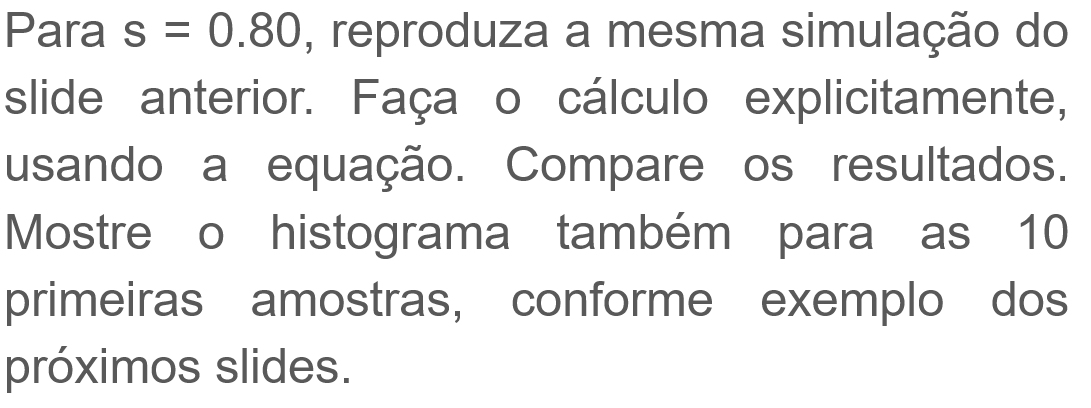

#### O que é uma Distribuição Binomial

A distribuição binomial é uma distribuição de probabilidade discreta que modela a contagem de sucessos em um conjunto de tentativas independentes. Cada tentativa tem apenas dois resultados possíveis, comumente chamados de "sucesso" e "falha", e uma probabilidade de sucesso constante em todas as tentativas.

As principais características de uma distribuição binomial incluem:

- Número fixo de tentativas n
- Tentativas independentes
- Probabilidade constante de sucesso p em cada tentativa
- Resultados binários por tentativa (sucesso/falha)

A importância da distribuição binomial na estatística vem de sua capacidade de modelar situações reais em que nos interessa a frequência com que um evento específico ocorre dentro de um número definido de tentativas.

#### Propriedades da Distribuição Binomial

**Número fixo de tentativas**

Dois parâmetros definem uma distribuição binomial:

- $n$: o número definido de tentativas independentes
- $p$: a probabilidade de sucesso em cada tentativa

Esses parâmetros determinam o formato e as características da distribuição.

Na modelagem estatística, esses parâmetros trazem implicações importantes. O $n$ fixo permite cálculos precisos de probabilidade em cenários com número de tentativas conhecido.

O $p$ constante nas tentativas permite modelar processos consistentes, embora possa limitar a aplicação quando a probabilidade de sucesso varia.

**Média e Variância**

Para uma distribuição binomial, a média (μ) e a variância (σ²) são calculadas como:

- Média = np
- Variância = $n\cdot p\cdot (1-p)$

A média representa o número esperado de sucessos em n tentativas. Por exemplo, ao jogar uma moeda justa 100 vezes ($n = 100$, $p = 0.5$), você espera 50 caras em média.

A variância quantifica a dispersão da distribuição em torno da média. Uma variância maior indica maior variabilidade no número de sucessos de um conjunto de tentativas para outro. Essa medida é útil para avaliar a confiabilidade de estimativas e construir intervalos de confiança.

**Simetria e Assimetria**

A probabilidade de sucesso p afeta o formato de uma distribuição binomial quando o número de tentativas n é fixo.

- Quando $p = 0.5$, a distribuição é simétrica.
- Quando $p < 0.5$, a distribuição apresenta assimetria positiva (cauda à direita).
- Quando $p > 0.5$, a distribuição apresenta assimetria negativa (cauda à esquerda).

O número de tentativas, indicado por n, influencia o formato da distribuição binomial. À medida que n aumenta, a distribuição tende progressivamente a uma curva em formato de sino. Essa mudança ocorre independentemente da probabilidade de sucesso p.

Ao mesmo tempo, a dispersão relativa da distribuição, medida pelo coeficiente de variação, diminui. Além disso, a assimetria reduz, trazendo mais simetria.

**Fórmula**

$$ P(X=k)=(\frac{n!}{k!(n-k)!})\cdot p^{k}\cdot (1-p)^{n-k}$$

### Código

In [ ]:
#  Função de destribuição Binomial
def binomial_func(ps, n, x):
    Px = (math.comb(n, x)) * (ps**(x)) * ((1-ps)**(n-x))
    return Px

### Comparação de Resultados

In [ ]:
a = binomial_func(0.95, 50, 48)
b = binomial_func(0.80, 50, 48)

print(f"O resultado da Probabilidade para as respectivas Taxa de Sucesso com total de 50 amostras, sendo 48 delas sucesso é:\n  Probabilidade A - (0.95): {a}\n  Probabilidae B - (0.80): {b}")

O resultado da Probabilidade para as respectivas Taxa de Sucesso com total de 50 amostras, sendo 48 delas sucesso é:
  Probabilidade A - (0.95): 0.2611013703988193
  Probabilidae B - (0.80): 0.001092736514728003


### Análise

Comparando os resultados, observa-se uma diferença bastante significativa entre as probabilidades obtidas para as duas taxas de sucesso. Para uma taxa de sucesso de 0,95, a probabilidade de obter 48 sucessos em 50 amostras é aproximadamente 0,2611 (26,11%), indicando que esse resultado é relativamente provável quando a taxa de sucesso verdadeira é alta. Por outro lado, para uma taxa de sucesso de 0,80, a probabilidade cai para aproximadamente 0,00109 (0,109%), tornando esse mesmo resultado extremamente improvável.

Isso ocorre porque obter 48 sucessos em 50 tentativas representa uma taxa observada de 96% de sucesso, valor muito próximo de 95%, mas bastante distante de 80%. Dessa forma, a distribuição binomial atribui uma probabilidade muito maior ao primeiro caso do que ao segundo.

Em termos relativos, o resultado para s=0,95 é cerca de 239 vezes mais provável do que para s=0,80, evidenciando que a escolha do parâmetro da distribuição influencia diretamente a probabilidade de ocorrência dos eventos observados.

### Gráfico

[8 7 9 7 7 6 7 7 9 9]


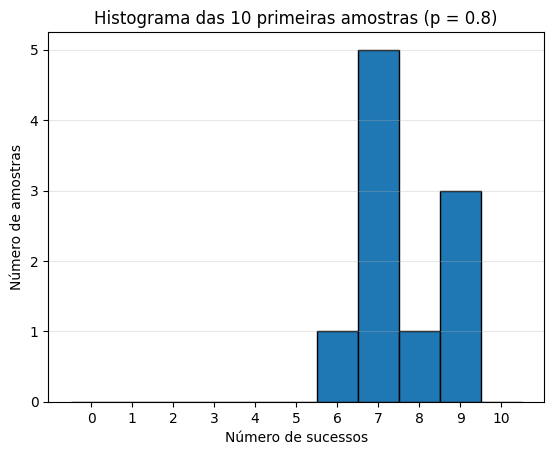

In [ ]:
# Exibição do Gráfico
# parâmetros
n = 10      # número de ensaios
p = 0.8     # success rate
num_amostras = 10

# gera 10 amostras binomiais
amostras = np.random.binomial(n, p, num_amostras)

print(amostras)

# histograma
plt.hist(amostras,
         bins=np.arange(-0.5, n + 1.5, 1),
         edgecolor='black')

plt.xticks(range(n + 1))
plt.xlabel("Número de sucessos")
plt.ylabel("Número de amostras")
plt.title("Histograma das 10 primeiras amostras (p = 0.8)")
plt.grid(axis="y", alpha=0.3)

plt.show()

# PARTE 2

---



## A ) Distribuição Amostral e Distribuição de Amostragem


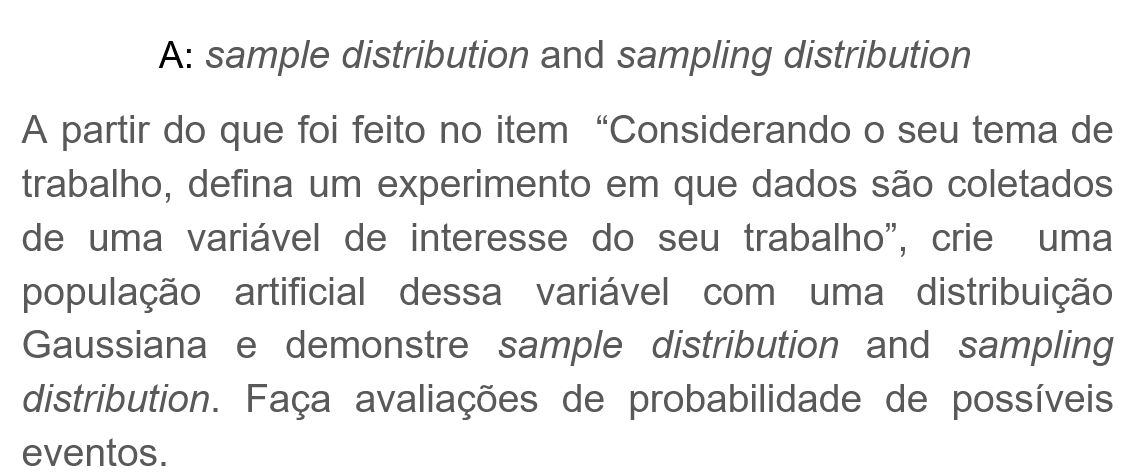

### Distribuição Amostral e Distribuição de Amostragem

Em Estatística, os conceitos de **Distribuição Amostral (Sample Distribution)** e **Distribuição de Amostragem (Sampling Distribution)** são diferentes, embora seus nomes sejam semelhantes.

**Distribuição Amostral (Sample Distribution)**

A Distribuição Amostral corresponde à distribuição dos valores observados em uma única amostra retirada da população. Ela descreve como os dados dessa amostra estão distribuídos.

Por exemplo, ao selecionar uma amostra de 50 sementes e analisar a variável **Compactness**, o histograma construído com esses 50 valores representa uma Distribuição Amostral.

Características:

- É formada pelos dados de uma única amostra.
- Mostra a variabilidade dos indivíduos observados.
- Possui sua própria média e desvio padrão.
- Pode ou não se parecer com a distribuição da população.

**Distribuição de Amostragem (Sampling Distribution)**

A Distribuição de Amostragem é a distribuição de uma estatística calculada a partir de muitas amostras extraídas da mesma população.

Por exemplo, se forem retiradas 5.000 amostras de tamanho 50 e for calculada a média de cada uma delas, a distribuição dessas 5.000 médias forma a Distribuição de Amostragem da média.

Características:

- É formada por uma estatística (média, proporção, variância, etc.).
- Utiliza várias amostras da mesma população.
- É utilizada para inferência estatística.
- Sua dispersão é medida pelo erro padrão.
- Está diretamente relacionada ao Teorema Central do Limite.

**Diferença entre os Conceitos**

| Distribuição Amostral | Distribuição de Amostragem |
|----------------------|----------------------------|
| Utiliza uma única amostra | Utiliza muitas amostras |
| Contém os valores observados | Contém estatísticas calculadas das amostras |
| Descreve os dados da amostra | Descreve o comportamento de uma estatística |
| Exemplo: histograma dos valores de Compactness de 50 sementes | Exemplo: histograma das médias de 5.000 amostras de tamanho 50 |

### Como ilustrado no Código

Considerando a variável **Compactness** do Seeds Dataset:

- O histograma dos valores de Compactness de uma amostra de 50 sementes representa uma **Distribuição Amostral**.
- O histograma das médias obtidas a partir de milhares de amostras de 50 sementes representa uma **Distribuição de Amostragem da Média**.

Assim, a Distribuição Amostral descreve os dados observados, enquanto a Distribuição de Amostragem descreve o comportamento de uma estatística calculada a partir de várias amostras.

### Código

In [54]:
mean_compact = df["compactness"].mean()
std_compact = df["compactness"].std()

In [55]:
# Criação da População Artificial com "random.normal"
artificial_population = np.random.normal(mean_compact, std_compact, 10000)

# Coleta de um grupo de amostras
compact_sample_1 = np.random.choice(artificial_population, size=50)

In [56]:
# Distribuição Amostral
compact_means = [np.mean(np.random.choice(artificial_population, size=50)) for i in range(1000)]

### Gráfico

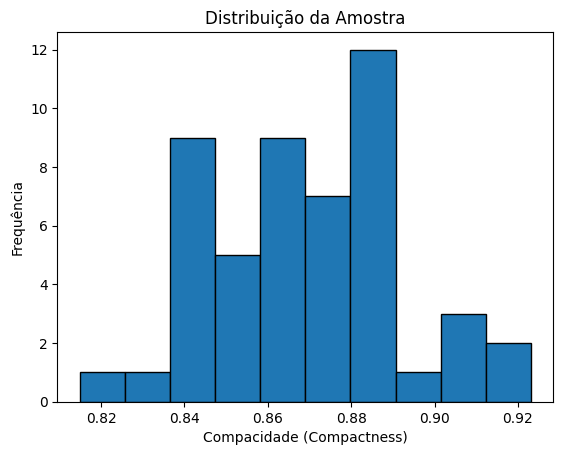

In [62]:
# Gráfico da Distribuição de uma Amostra
plt.hist(compact_sample_1, bins=10, edgecolor="black")
plt.xlabel("Compacidade (Compactness)")
plt.ylabel("Frequência")
plt.title("Distribuição da Amostra")
plt.show()

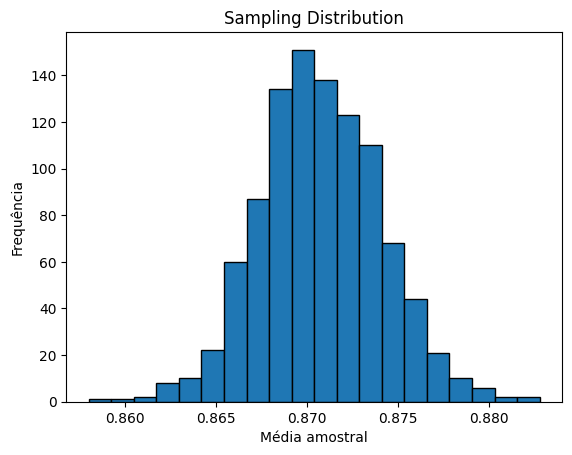

In [63]:
# Gráfico da Distribuição Amostral
plt.hist(compact_means, bins=20, edgecolor="black")
plt.xlabel("Média amostral")
plt.ylabel("Frequência")
plt.title("Sampling Distribution")
plt.show()

### Possíveis Eventos

Qual a probabilidade de uma semente possuir Compacidade ($Compactness > 0.90$)?

In [65]:
prob_teorica = 1 - norm.cdf(0.90, mean_compact, std_compact)
prob_empirica = np.mean(artificial_population > 0.90)

print("Evento 1: Compactness > 0.90")
print("Probabilidade Teórica:", prob_teorica)
print("Probabilidade Empírica:", prob_empirica)

Evento 1: Compactness > 0.90
Probabilidade Teórica: 0.10984661536762852
Probabilidade Empírica: 0.1054


Qual a probabilidade de uma semente apresentar Compacidade $(Compactness < 0.80)$?

In [66]:
prob_teorica = norm.cdf(0.80, mean_compact, std_compact)
prob_empirica = np.mean(artificial_population < 0.80)

print("Evento 2: Compactness < 0.80")
print("Probabilidade Teórica:", prob_teorica)
print("Probabilidade Empírica:", prob_empirica)

Evento 2: Compactness < 0.80
Probabilidade Teórica: 0.0013293508025959847
Probabilidade Empírica: 0.0015


Qual a probabilidade de uma semente apresentar Compacidade $(0.85 < Compactness < 0.90)$?

In [68]:
prob_teorica = (norm.cdf(0.90, mean_compact, std_compact)- norm.cdf(0.85, mean_compact, std_compact))
prob_empirica = np.mean((artificial_population > 0.85) & (artificial_population < 0.90))

print("Evento 3: 0.85 < Compactness < 0.90")
print("Probabilidade Teórica:", prob_teorica)
print("Probabilidade Empírica:", prob_empirica)

Evento 3: 0.85 < Compactness < 0.90
Probabilidade Teórica: 0.7030610826450452
Probabilidade Empírica: 0.7063


Qual a probabilidade de a média de uma amostra de 50 sementes apresentar Compacidade $(Compactness > 0.88)$?

In [70]:
prob_empirica = np.mean(np.array(compact_means) > 0.88)

print("Evento 4: Média Amostral > 0.88")
print("Probabilidade Empírica:", prob_empirica)

Evento 4: Média Amostral > 0.88
Probabilidade Empírica: 0.006


## B ) Teorema do Limite Central

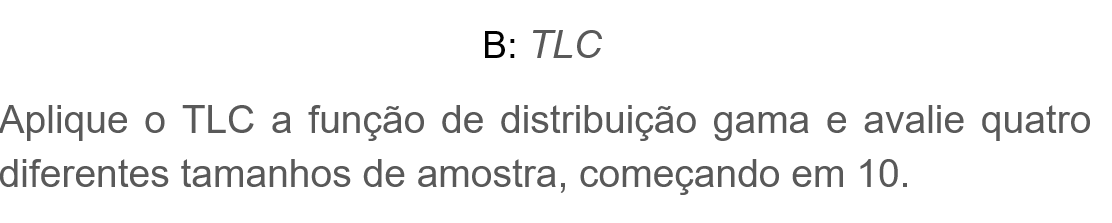

### O que é o Teorema Central do Limite

O **Teorema Central do Limite (TLC)** é um dos resultados mais importantes da Estatística. Ele afirma que, independentemente da distribuição original dos dados, a distribuição das médias amostrais tende a se aproximar de uma distribuição Normal à medida que o tamanho da amostra aumenta.

Em outras palavras, mesmo que a população possua uma distribuição assimétrica, como a distribuição Gama, as médias obtidas a partir de várias amostras tendem a formar uma distribuição aproximadamente Gaussiana quando o número de observações em cada amostra é suficientemente grande.

Matematicamente, para uma população com média $(\mu)$ e desvio padrão $(\sigma)$, a distribuição das médias amostrais possui:

- Média:

$$ E(\bar{X}) = \mu $$

- Desvio padrão (erro padrão):

$$\sigma_{\bar{X}} = \frac{\sigma}{\sqrt{n}}$$

onde:

- $(\bar{X})$ é a média amostral;
- $(\mu)$ é a média da população;
- $(\sigma)$ é o desvio padrão da população;
- $(n)$ é o tamanho da amostra.

Uma consequência importante do TLC é que, conforme o tamanho da amostra aumenta, as médias amostrais ficam mais concentradas em torno da média populacional e sua distribuição torna-se cada vez mais próxima de uma distribuição Normal. Esse resultado justifica o uso de diversos métodos estatísticos que assumem normalidade, mesmo quando os dados originais não seguem uma distribuição Normal.

### Código e Gráfico

In [31]:
mean_compactness = df["compactness"].mean()
variance_compactness = df["compactness"].var()

alpha = mean_compactness**2 / variance_compactness
theta = variance_compactness / mean_compactness

In [41]:
# Semente fixa
np.random.seed(42)

In [32]:
gama_population = np.random.gamma(alpha, theta, 100000)

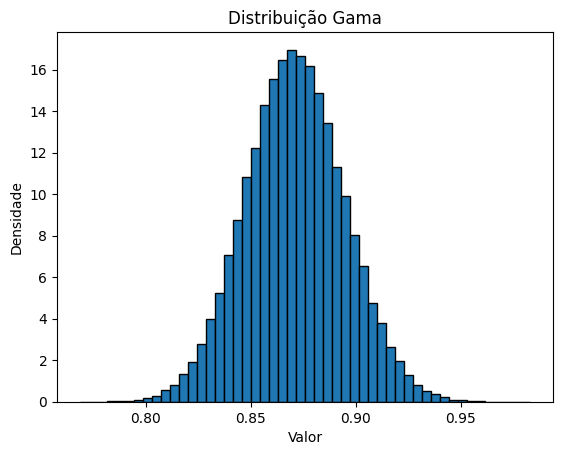

In [33]:
plt.hist(gama_population, bins=50, density=True, edgecolor='black')
plt.title("Distribuição Gama")
plt.xlabel("Valor")
plt.ylabel("Densidade")
plt.show()

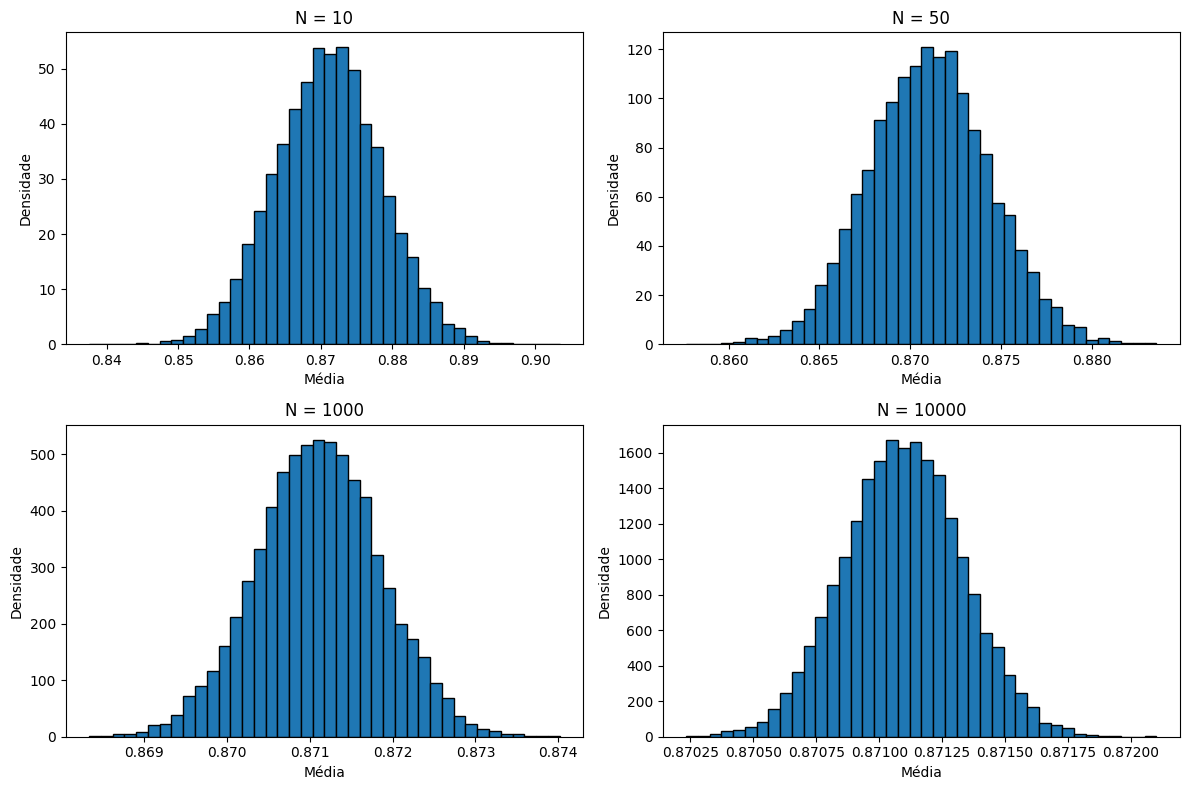

In [47]:
# Gráfico
tamanhos = [10, 50, 1000, 10000]

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for ax, n in zip(axs.flat, tamanhos):

    medias = [np.mean(np.random.choice(gama_population, size=n)) for i in range(10000)]

    ax.hist(medias, bins=40, density=True, edgecolor='black')
    ax.set_title(f"N = {n}")
    ax.set_xlabel("Média")
    ax.set_ylabel("Densidade")

plt.tight_layout()
plt.show()

### Análise

A população artificial foi gerada a partir de uma distribuição Gama ajustada aos dados da variável Compactness. Em seguida, foram extraídas amostras de tamanhos 10, 50, 1000 e 10000, calculando-se a média de cada amostra.

Se observa que, à medida que o tamanho amostral aumenta, a distribuição das médias torna-se progressivamente mais simétrica e próxima de uma distribuição Normal. Além disso, a dispersão das médias diminui, concentrando-se cada vez mais em torno da média populacional.

Esse comportamento confirma experimentalmente o Teorema Central do Limite, que estabelece que a distribuição das médias amostrais tende à Normal conforme o tamanho da amostra cresce, independentemente da distribuição original dos dados.



##  C ) P-Valor

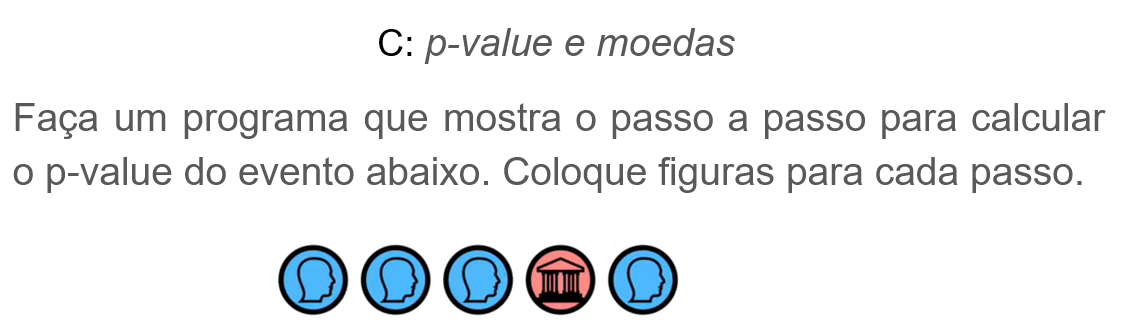

### Teste de Hipótese

É uma metodologia estatística que nos auxilia a tomar decisões baseado na informação obtida da amostra.

Nos permite verificar se os dados amostrais trazem evidência que apoiem ou não uma hipótese estatística formulada.

Ao tentarmos tomar decisões, é conveniente a formulação de suposições ou de conjeturas sobre as populações de interesse, que, em geral, consistem em considerações sobre parâmetros (μ,σ2,p) das mesmas.

Essas suposições, que podem ser ou não verdadeiras, são denominadas de Hipóteses Estatísticas.

O teste de hipóteses fornecem ferramentas que nos permitem rejeitar ou não rejeitar uma hipótese estatística através da evidencia fornecida pela amostra.

- Hipótese Nula ($H_0$)
- Hipótese Alternativa.($H_1$)

Com uma observação sobre a Hipótese Nula:
- Sempre estabeleceremos a hipótese nula $H_0$ como uma afirmação de igualdade.

**Tipos de Erro**
É possível interpretar melhor na figura a baixo.
- Erro do Tipo I: Rejeitar a hipótese nula $H_0$ quando ela é verdadeira
- Erro do Tipo II: Não Rejeitar a hipótese nula $H_0$ quando ela é falsa

**Tipos de Teste**
Existem os paramétricos e os não paramétricos.

Os testes paramétricos assumem que os dados seguem uma distribuição específica (geralmente normal) e possuem variâncias homogêneas.

Eles são mais poderosos quando essas suposições são atendidas, pois utilizam mais informações sobre os dados.

**Paramétricos:**

**Teste t de Student** (para uma ou duas amostras): compara médias de uma ou duas populações.

- Hipótese nula (H₀): não há diferença entre as médias (μ1=μ2).
- Hipótese alternativa (H₁​): as médias são diferentes (μ1≠μ2).

**Teste z**: semelhante ao teste t, mas usado para grandes amostras (quantidade de elementos n>30) ou quando a variância populacional é conhecida.

- Hipótese nula (H₀): a média da amostra é igual à média da população (X=μ).
- Hipótese alternativa (H₁​): a média da amostra é diferente da média da população (X≠μ).

**Teste qui-quadrado** (χ2): avalia associações entre variáveis categóricas ou adequação de um modelo teórico.

- Hipótese nula (H₀): não há associação entre as variáveis.
- Hipótese alternativa (H₁​): existe associação entre as variáveis.

**Teste F (ANOVA)**: compara médias de três ou mais grupos.

- Hipótese nula (H₀): as médias dos grupos são iguais.
- Hipótese alternativa (H₁​): pelo menos uma média é diferente.

**Não Paramétricos:**

Os testes não paramétricos não dependem de suposições rígidas sobre a distribuição dos dados.

Eles são mais versáteis e usados quando as condições dos testes paramétricos não são atendidas. Alguns deles: Teste de Mann-Whitney, Teste de Wilcoxon, Teste de Kruskal-Wallis, Teste de Friedman.

**Testes unicaudais e bicaudais**

**Teste unicaudal**: verificar se os valores estão em uma direção específica (por exemplo, se um grupo é maior ou menor que o outro). Usamos testes unicaudais quando já temos uma ideia clara da direção da diferença antes de realizar o teste.

- Hipótese nula (H₀): não há diferença na direção esperada. Exemplo: μ1 ≤ μ2​ (o grupo 1 é menor ou igual ao grupo 2).
- Hipótese alternativa (H₁​): existe uma diferença na direção esperada. Exemplo: μ1 > μ2 (o grupo 1 é maior que o grupo 2).

**Teste bicaudal**: verifica se há uma diferença em qualquer direção (ou seja, se um grupo é maior ou menor que o outro). Usamos testes bicaudais quando não sabemos antecipadamente em que direção a diferença pode ocorrer.

- Hipótese nula (H₀): não há diferença entre os grupos. Exemplo: μ1=μ2​ (os dois grupos são iguais).
- Hipótese alternativa (H₁​): existe diferença em qualquer direção. Exemplo: μ1≠μ2 (os grupos são diferentes).

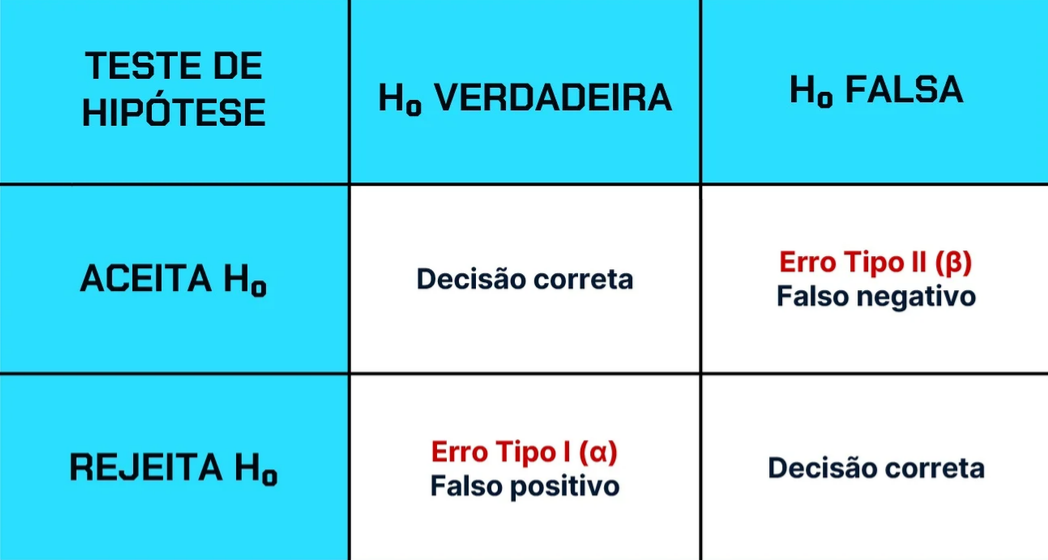

### O que é P-Value

O p-valor é a probabilidade de se obter uma estatística de teste tão extrema (ou mais extrema) quanto a observada, dado que a hipótese nula é verdadeira.

Ele existe no contexto da inferência estatística, quando estamos analisando dados de uma amostra para tirar conclusões sobre uma população maior.

Pode ser interpretado como uma forma de auxiliar no jeito de avaliar se as diferenças encontradas entre as amostras são apenas fruto do acaso ou se refletem um efeito real.

Ainda sim, O p-valor apenas indica a probabilidade do resultado observado ser obtido e deve ser sempre analisado junto a outras informações.

### Definindo as Hipóteses

- Hipótese Nula ($H_0$): A moeda é normal.

- Hipótese Alternativa ($H_1$): A moeda é especial.

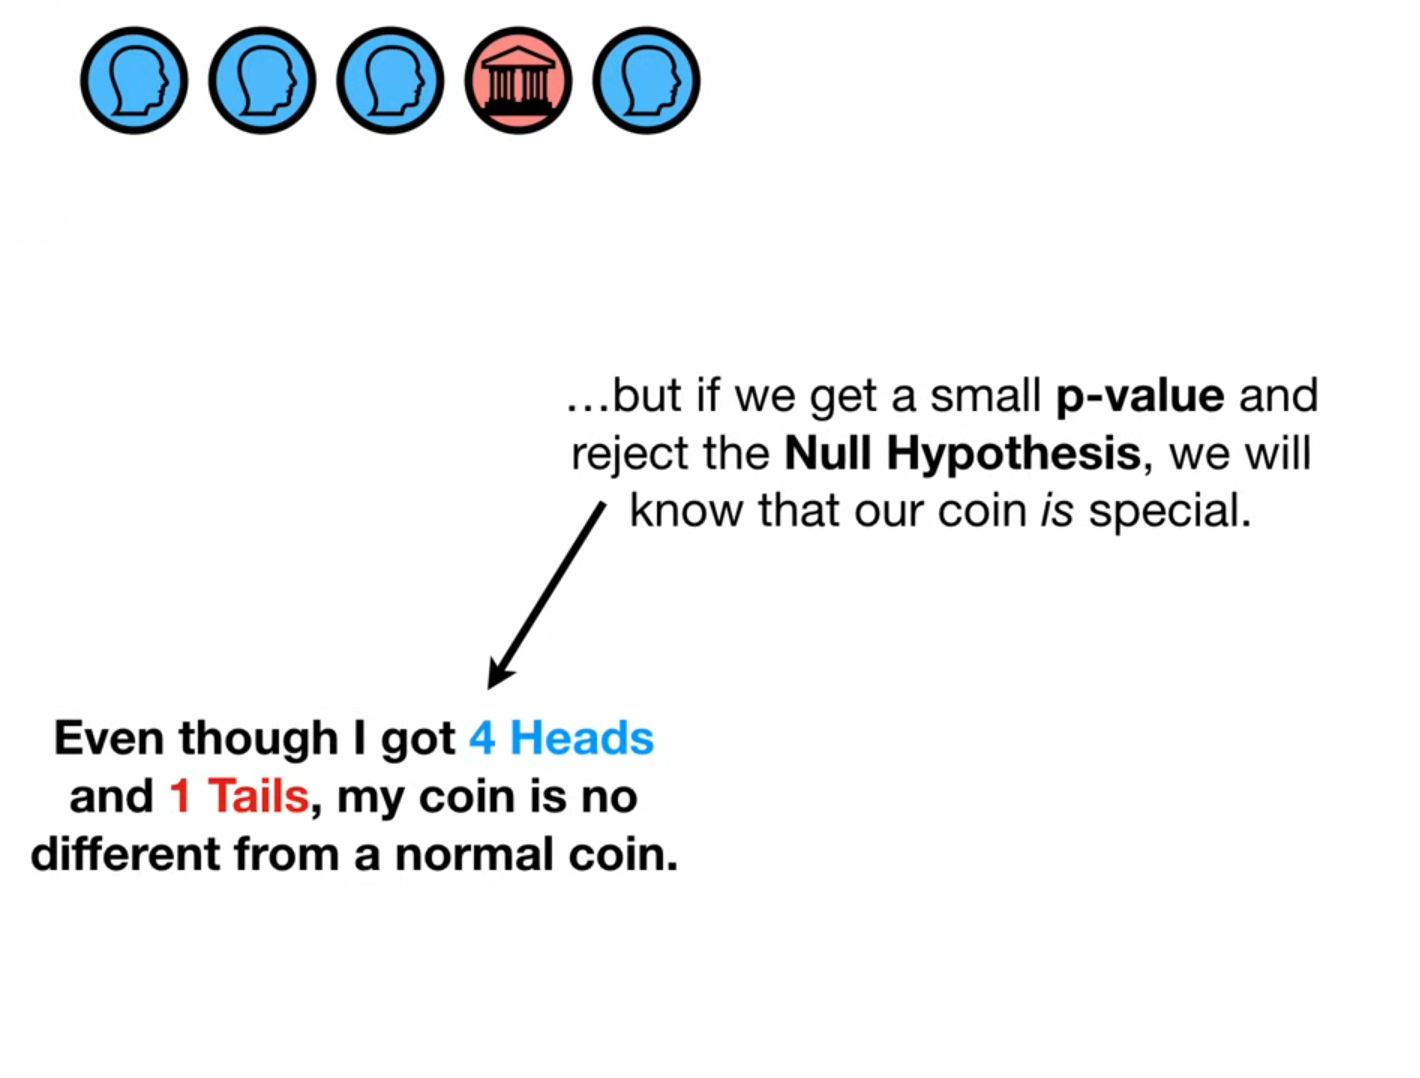

### Código e Análise

In [ ]:
# As ocorrências
print(f"{'Frequências':<15} {'Caras':<6} {'Coroas':<6}")

for seq in product(["C", "Ȼ"], repeat=5):
    caras = seq.count("C")
    coroas = seq.count("Ȼ")
    print(f"{' '.join(seq):<17} {caras:<7} {coroas:<6}")

Frequências     Caras  Coroas
C C C C C         5       0     
C C C C Ȼ         4       1     
C C C Ȼ C         4       1     
C C C Ȼ Ȼ         3       2     
C C Ȼ C C         4       1     
C C Ȼ C Ȼ         3       2     
C C Ȼ Ȼ C         3       2     
C C Ȼ Ȼ Ȼ         2       3     
C Ȼ C C C         4       1     
C Ȼ C C Ȼ         3       2     
C Ȼ C Ȼ C         3       2     
C Ȼ C Ȼ Ȼ         2       3     
C Ȼ Ȼ C C         3       2     
C Ȼ Ȼ C Ȼ         2       3     
C Ȼ Ȼ Ȼ C         2       3     
C Ȼ Ȼ Ȼ Ȼ         1       4     
Ȼ C C C C         4       1     
Ȼ C C C Ȼ         3       2     
Ȼ C C Ȼ C         3       2     
Ȼ C C Ȼ Ȼ         2       3     
Ȼ C Ȼ C C         3       2     
Ȼ C Ȼ C Ȼ         2       3     
Ȼ C Ȼ Ȼ C         2       3     
Ȼ C Ȼ Ȼ Ȼ         1       4     
Ȼ Ȼ C C C         3       2     
Ȼ Ȼ C C Ȼ         2       3     
Ȼ Ȼ C Ȼ C         2       3     
Ȼ Ȼ C Ȼ Ȼ         1       4     
Ȼ Ȼ Ȼ C C         2       3     
Ȼ Ȼ Ȼ C Ȼ    

Os possíveis resultados podem ser observados melhor a seguir:

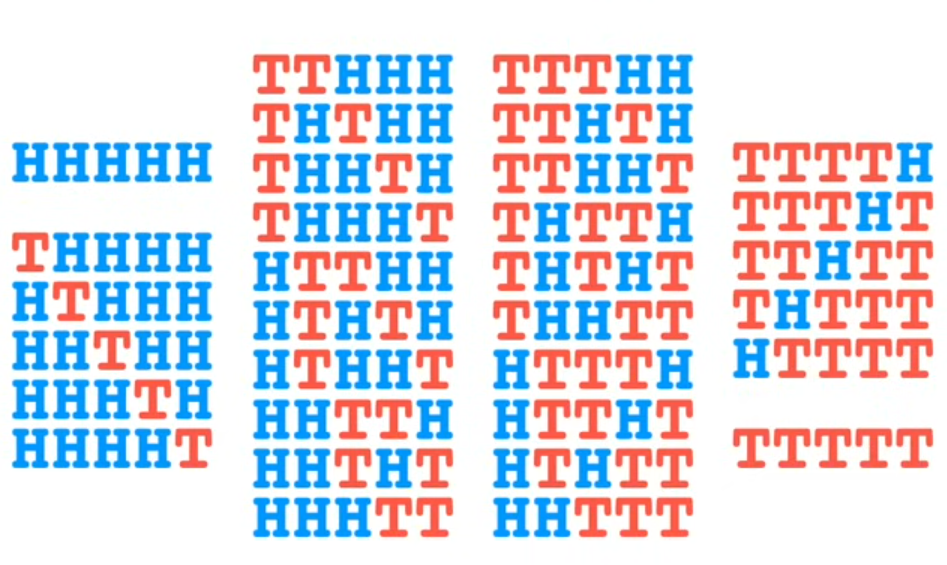

Os possíveis resultados de se jogar uma moeda 5 vezes são esses da imagem a cima, onde H(Cara) e T(Coroa).

Totalizando 32 resultados possíveis de ocorrer.

Os resultados possíveis tem a frequência de:

In [ ]:
# Encontrar a frequência em que ocorre os casos com combinação
combinacao_5 = math.comb(5, 0)
combinacao_4 = math.comb(5, 1)
combinacao_3 = math.comb(5, 2)
combinacao_2 = math.comb(5, 3)
combinacao_1 = math.comb(5, 4)
combinacao_0 = math.comb(5, 5)
total =  combinacao_5 + combinacao_4 + combinacao_3 + combinacao_2 + combinacao_1 + combinacao_0

print("0 caras | 5 coroas:", combinacao_5)
print("1 cara  | 4 coroas:", combinacao_4)
print("2 caras | 3 coroas:", combinacao_3)
print("3 caras | 2 coroas:", combinacao_2)
print("4 caras | 1 coroas:", combinacao_1)
print("5 caras | 0 coroas:", combinacao_0)
print("Total de Eventos: ", total)

0 caras | 5 coroas: 1
1 cara  | 4 coroas: 5
2 caras | 3 coroas: 10
3 caras | 2 coroas: 10
4 caras | 1 coroas: 5
5 caras | 0 coroas: 1
Total de Eventos:  32


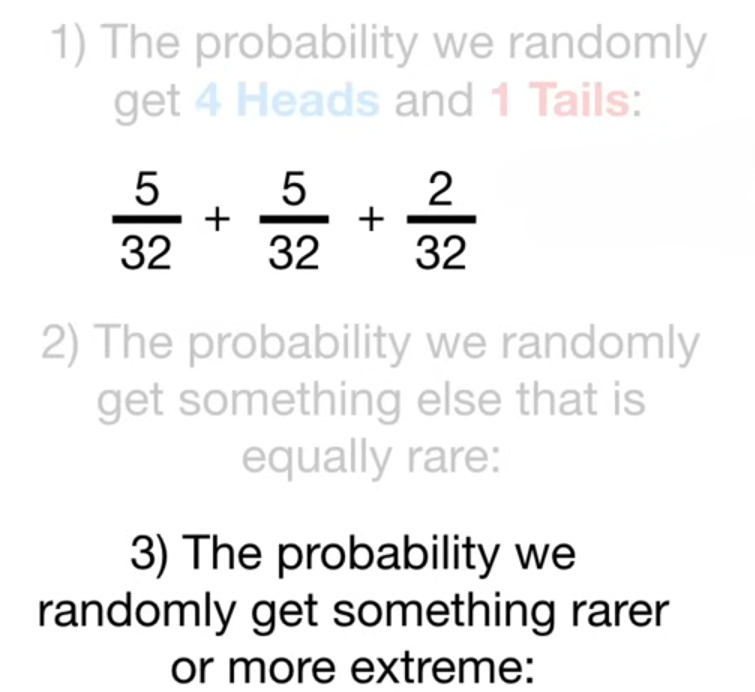

A imagem a cima define como o P-Valor é calculado, basicamente é a soma dos eventos que se deseja observar divididos pelo total mais os eventos de igual chance divididos pelo total mais o eventos mais raros que esse dividido pelo total.

In [ ]:
# P-Valor
# Se procura o p-value do evento: 4 Caras e 1 Coroa
# A primeira parte é a probabilidade de
p_value = (combinacao_1/total) + (combinacao_4/total) + ((combinacao_0 + combinacao_5)/total)
print(p_value)

0.375


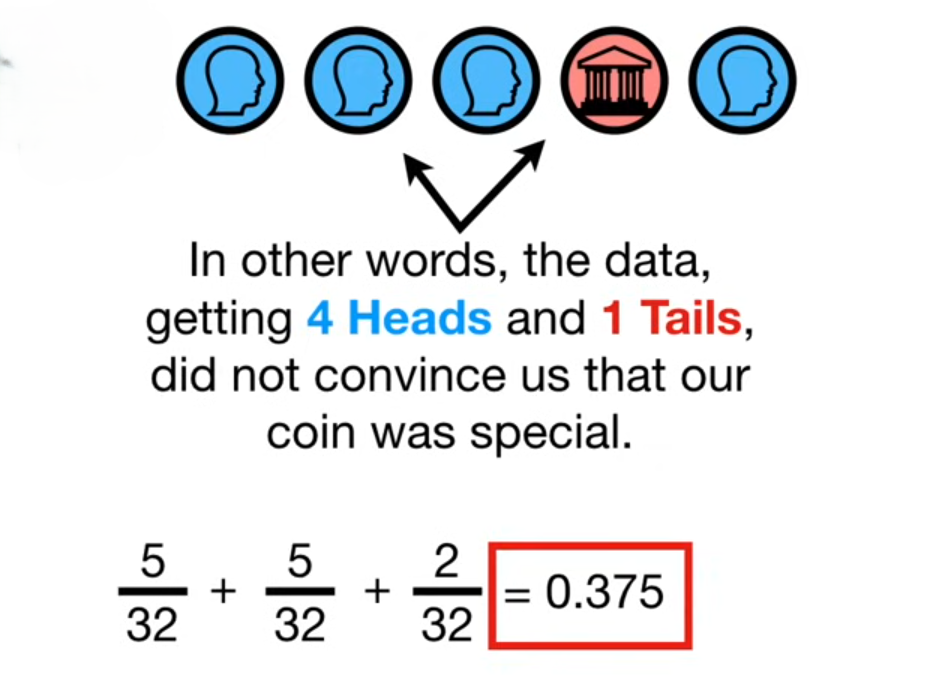

Com esse resultado pode se chegar a uma conclusão:
- Houve falha em rejeitar a Hipótese Nula.


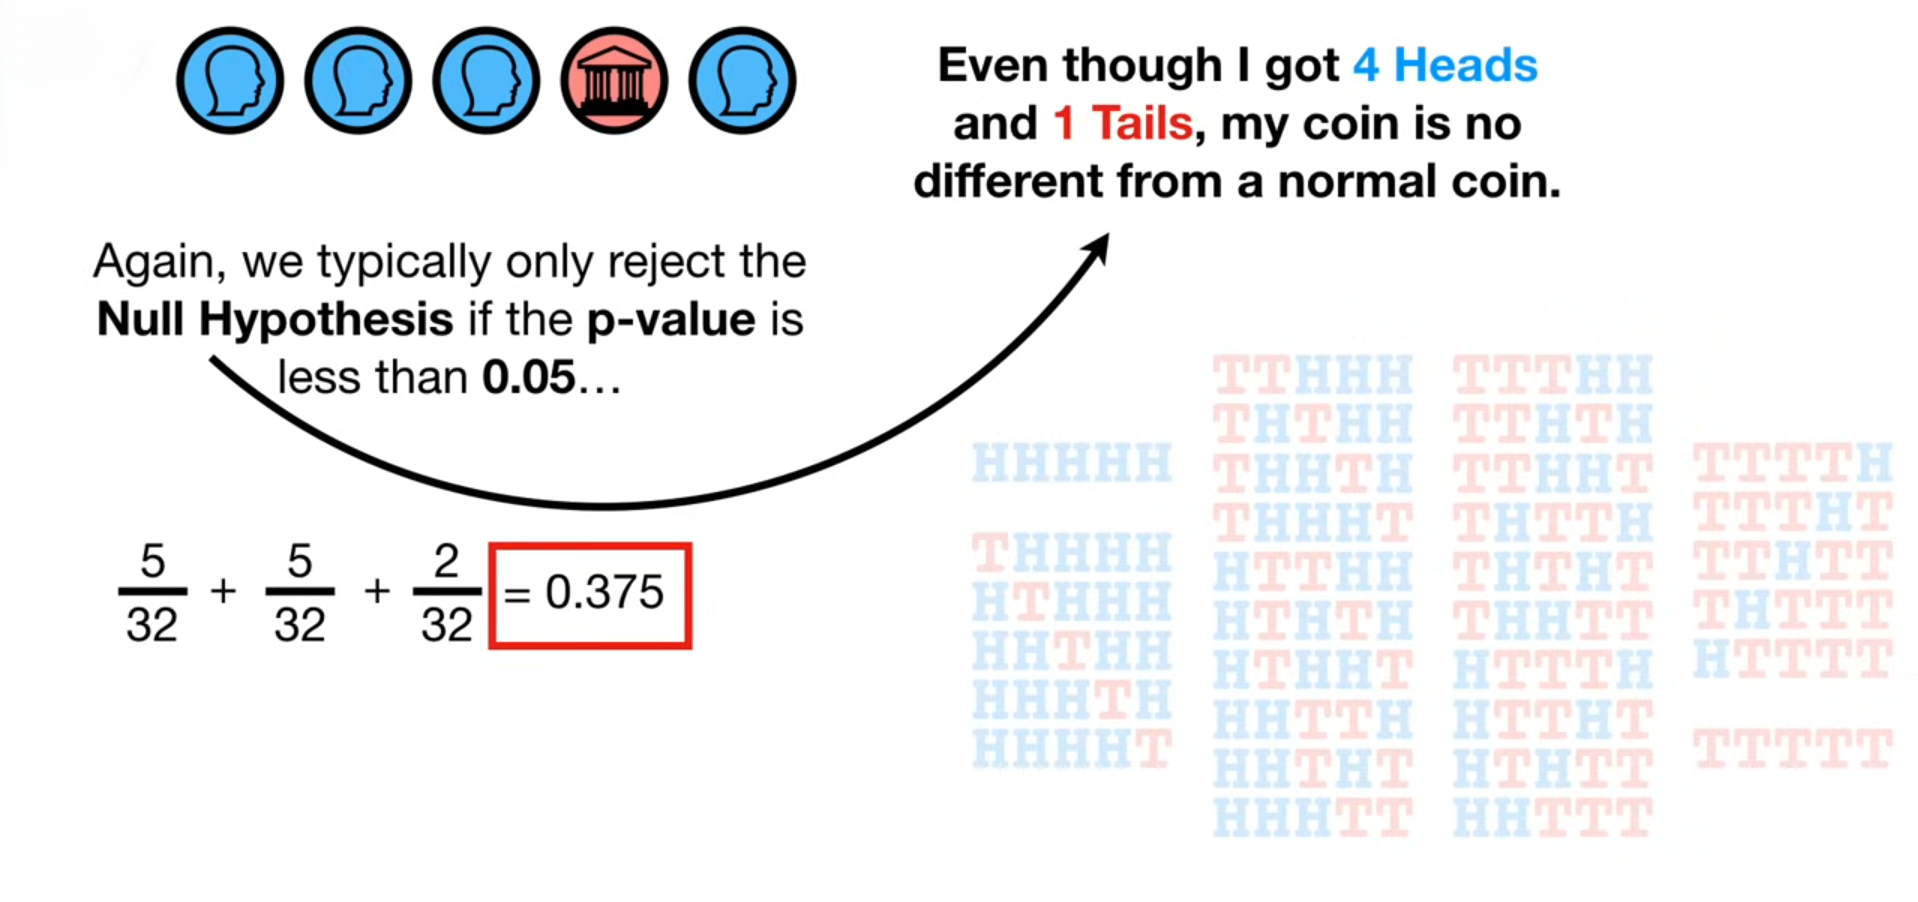

A razão de ter falhado é porque o p-value resultante foi de $0.375$ que é maior do que $0.05$, tendo em vista que o resultado foi maior que o nível de significância de $5\%$.

## D ) P-Valor

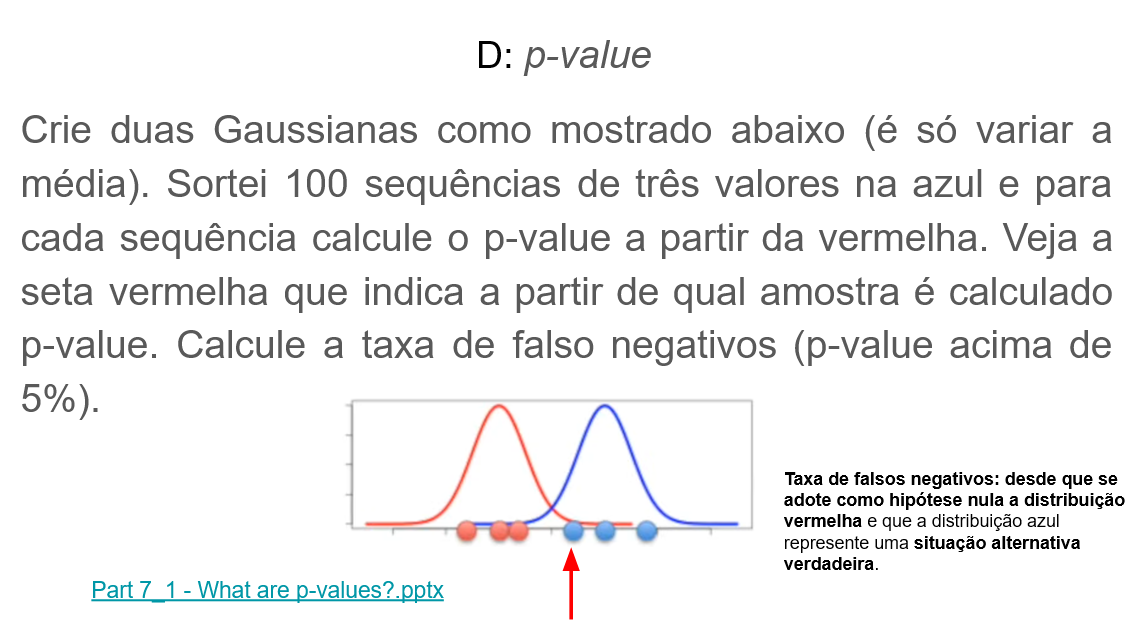

### Z-Score

O **Z-Score** é uma medida que indica quantos desvios-padrão (ou erros-padrão, no caso da média amostral) um valor observado está distante da média esperada pela hipótese nula. Ele é utilizado para padronizar os dados e permitir o cálculo do p-value.


### Fórmula e Intepretação

$$z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}$$

Onde:
- $(\bar{x})$: média da amostra observada.
- $(\mu_0)$: média da hipótese nula $H_0$.
- $(\sigma)$: desvio padrão da população.
- $(n)$: tamanho da amostra.
- $(\sigma / \sqrt{n})$: erro padrão da média.

Quanto maior o valor absoluto do Z-Score, mais distante a média observada está da média esperada pela hipótese nula. Valores de Z muito altos ou muito baixos indicam que a amostra é pouco compatível com $(H_0)$, resultando em p-values menores e aumentando a evidência para rejeitar a hipótese nula.

### Definindo as Hipóteses

- Hipótese Nula ($H_0$): Os dados vem da Distribuição Vermelha.

- Hipótese Alternativa ($H_1$): Os dados vem da Distribuição Azul.

- Nível de Significância: $5\%$

### Código


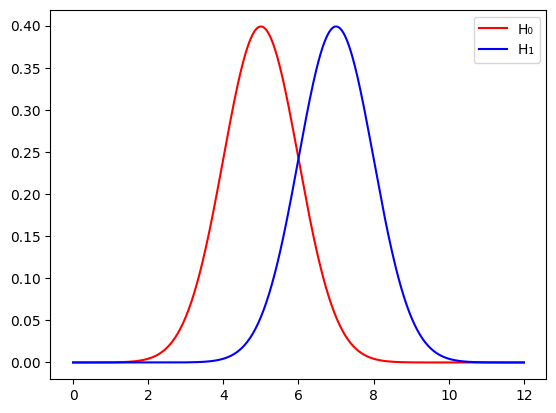

In [44]:
# Gráfico das duas Gaussianas
media_v = 5
media_a = 7
desvio = 1

x = np.linspace(0, 12, 500)

plt.plot(x, norm.pdf(x, media_v, desvio), color="red", label="H₀")
plt.plot(x, norm.pdf(x, media_a, desvio), color="blue", label="H₁​")

plt.legend()
plt.show()

In [45]:
# Gerando sequências de 3 números aleatórias para o experimento:
sequencias = [np.random.normal(media_a, desvio, 3) for i in range(100)]

In [46]:
p_values = []

for sequencia in sequencias:

    media_amostral = np.mean(sequencia)
    erro_padrao = desvio / np.sqrt(3)
    # Z-Score calculado baseado na gaussiana vermelha:
    z = (media_amostral - media_v) / erro_padrao

    # calcula a área sob a curva normal
    p_value = 1 - norm.cdf(z)
    p_values.append(p_value)

    print(f"Amostra: {sequencia}")
    print(f"Média: {media_amostral:.3f}")
    print(f"p-value: {p_value:.12f}")
    if p_value < 0.05:
        print("Rejeita H₀\n")
    else:
        print("Não rejeita H₀\n")

Amostra: [8.33728568 5.43166963 7.89000966]
Média: 7.220
p-value: 0.000060385645
Rejeita H₀

Amostra: [7.45584475 7.34262604 5.72705466]
Média: 6.842
p-value: 0.000710961359
Rejeita H₀

Amostra: [7.56743824 7.78021652 6.20180009]
Média: 7.183
p-value: 0.000077996514
Rejeita H₀

Amostra: [7.8636808  6.68742043 6.2090011 ]
Média: 6.920
p-value: 0.000441147555
Rejeita H₀

Amostra: [7.12395192 5.51268355 5.92464108]
Média: 6.187
p-value: 0.019886247566
Rejeita H₀

Amostra: [8.22615148 7.65486063 7.00737059]
Média: 7.629
p-value: 0.000002627267
Rejeita H₀

Amostra: [6.65114822 8.56860542 5.64777896]
Média: 6.956
p-value: 0.000352507381
Rejeita H₀

Amostra: [8.29174429 7.85830824 6.91822063]
Média: 7.689
p-value: 0.000001594779
Rejeita H₀

Amostra: [6.69500833 5.66987895 7.61101659]
Média: 6.659
p-value: 0.002034004032
Rejeita H₀

Amostra: [5.74599449 5.60564654 8.09447549]
Média: 6.482
p-value: 0.005129625190
Rejeita H₀

Amostra: [6.2051485  5.47063067 7.58407756]
Média: 6.420
p-value: 0.00

### Análise

Foram geradas 100 amostras com tamanho 3 com base na distribuição azul, para cada amostra, foi calculado o p-value assumindo que os dados pertenciam à distribuição vermelha. Quando o p-value da sequência era menor que $0.05$, a hipótese nula era rejeitada, indicando que a amostra provavelmente não veio da distribuição vermelha.

Já quando o p-value foi maior que $0.05$, a hipótese nula não foi rejeitada. Como as amostras foram geradas pela distribuição azul, esses casos representam falsos negativos (erro tipo II), ou seja, situações em que a hipótese nula é falsa, mas não foi rejeitada pelo teste.

# PARTE 3

## A ) Correlação com o Tema


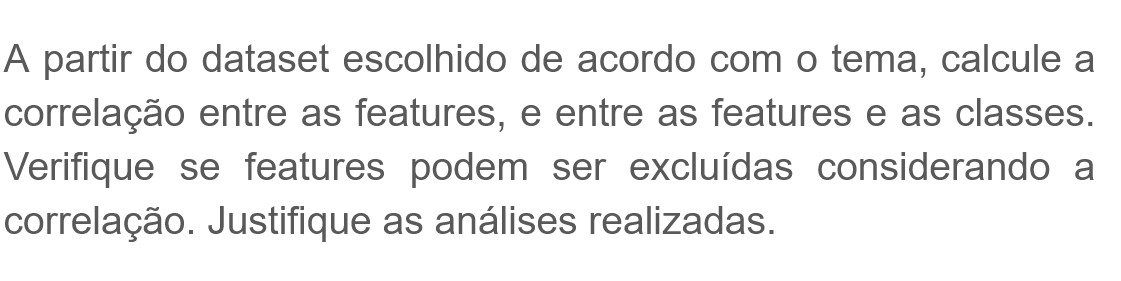

### Gráfico de Correlação Geral (Sem restrição por Classe)

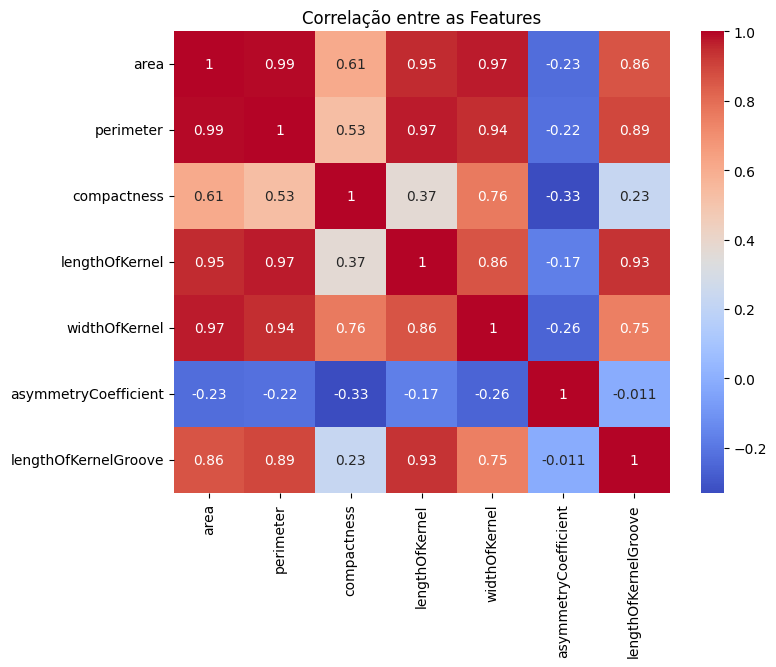

In [58]:
# Gráfico de Correlação entre as Características (Features)
plt.figure(figsize=(8,6))
corr_features = df.drop(columns=["ID", "seedType"]).corr()
sns.heatmap(corr_features, annot=True, cmap="coolwarm")
plt.title("Correlação entre as Features")
plt.show()

De forma geral, as variáveis "Area" e "Perimeter" apresentaram correlação muito forte (r = 0.99), indicando alta redundância de informação. Uma delas poderia ser removida para reduzir dimensionalidade sem grande perda informacional, contanto que seja bem avaliado o que o modelo mais priorizaria, ou se é viável de fato remover uma delas.

### Gráfico Classe 1:

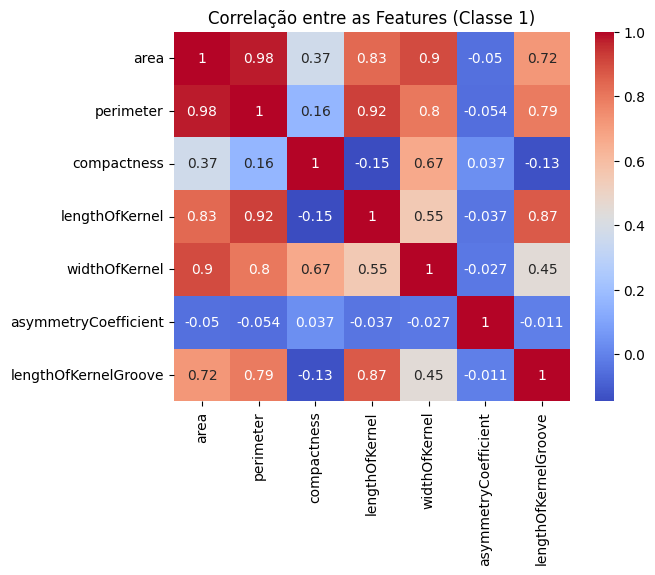

In [60]:
classe_1 = df[df["seedType"] == 1]
correlation_c1 = classe_1.drop(columns=["ID", "seedType"]).corr()

sns.heatmap(correlation_c1, annot=True, cmap="coolwarm")
plt.title("Correlação entre as Features (Classe 1)")
plt.show()

### Gráfico Classe 2:

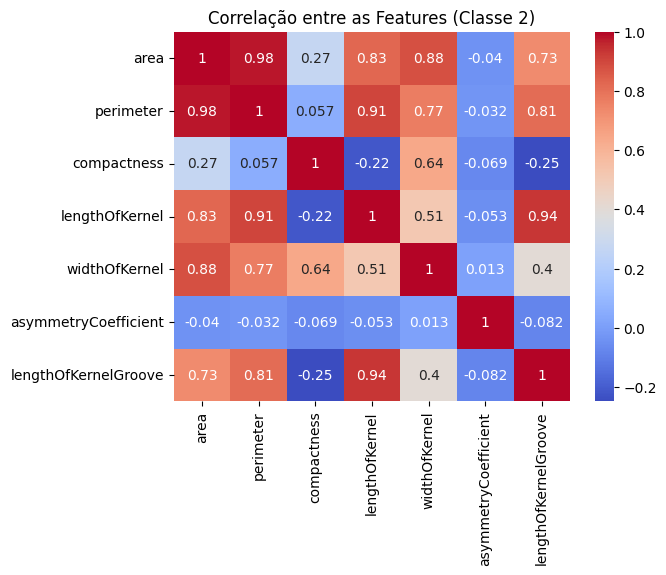

In [62]:
classe_2 = df[df["seedType"] == 2]
correlation_c2 = classe_2.drop(columns=["ID", "seedType"]).corr()

sns.heatmap(correlation_c2, annot=True, cmap="coolwarm")
plt.title("Correlação entre as Features (Classe 2)")
plt.show()

### Gráfico Classe 3:

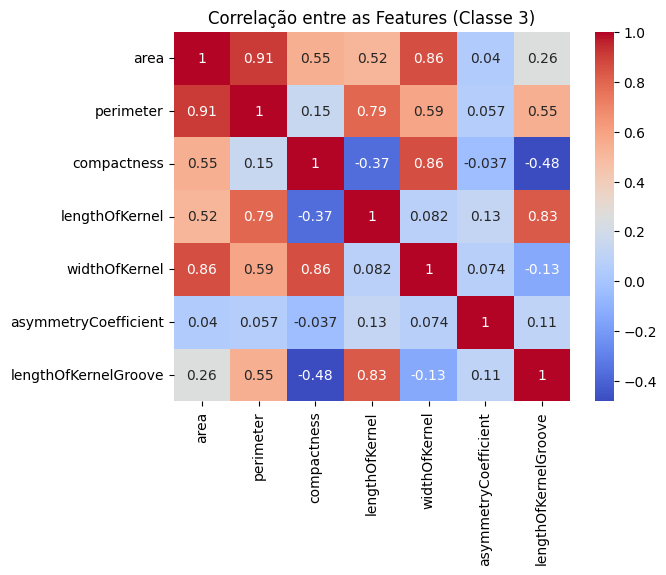

In [63]:
classe_3 = df[df["seedType"] == 3]
correlation_c3 = classe_3.drop(columns=["ID", "seedType"]).corr()

sns.heatmap(correlation_c3, annot=True, cmap="coolwarm")
plt.title("Correlação entre as Features (Classe 3)")
plt.show()

### Features que podem ser excluídas

Para a Classe 1, as features que podem ser eleitas a remoção são a "Area" e a "Perimeter", possuindo uma correlação de $98\%$ entre si.

Para a Classe 2, as features que podem ser eleitas a remoção são a "Area" e a "Perimeter", possuindo uma correlação de $98\%$ entre si.

Para a Classe 3, as features que podem ser eleitas a remoção são a "Area" e a "Perimeter", possuindo uma correlação de $91\%$ entre si, apesar de que acredito que abaixo de $95\%$ o valor já é muito baixo para remover algumas dessas features motivado por uma redundância de dados.

## B ) Correlação dos slides

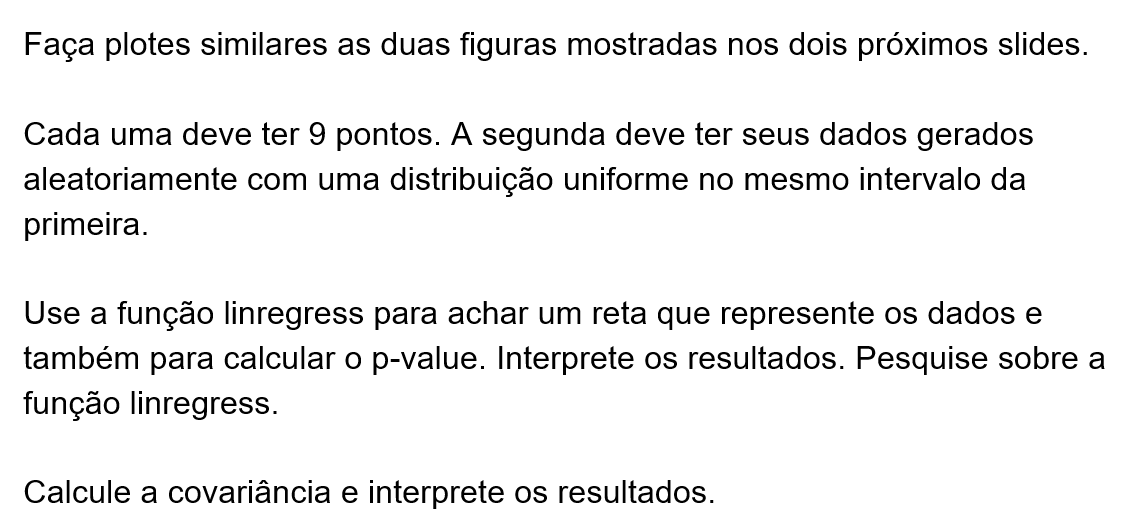

Gerar valores similares aos das seguintes figuras, para isso define-se primeiramente uma "semente", que define valores iniciais para geradores de números pseudoaleatórios, com o objetivo de garantir a reprodutibilidade, o que facilita futuras análises de resultado.

In [64]:
np.random.seed(3994)

Função Linregress:

A função Linregress retorna:
- o slope(coeficiente angular)
- o intercept(coeficiente linear)
- o r-value(coeficiente de correlação Pearson)
- o p-value(valor de probabilidade)
- o stderr(erro padrão do coeficiente angular)
- o intercept_stderr(erro padrão do coeficiente linear)

### Código

In [70]:
# Gráfico 1
x1 = np.random.rand(9) * 2 + 1                              # Cria um vetor com números float aleatórios entre (0,1) e os valores são multiplicados por 2 e soma por 1, é uma distribuição uniforme
y1 = x1 + 0.1                                               # Função y em que cada x da lista é somado com mais 0.1
                                                            # x1 e y1 são para o gráfico 1

media_x1 = sum(x1) / len(x1)                                # Média do X do gráfico 1
media_y1 = sum(y1) / len(y1)                                # Média do Y do gráfico 1
covariancia_1 = sum((x1[i] - media_x1) * (y1[i] - media_y1) for i in range(len(x1)) ) / (len(x1) - 1)
                                                            # Cálculo da covariância usando list comprehension
resultado1 = stats.linregress(x1, y1)                       # Nesta parte realiza-se a Regressão Linear para o gráfico 1
pvalue1 = resultado1.pvalue                                 # Valor de probabilidade retornado pela Regressão Linear 1

linha_X1 = np.linspace(0, 4, 2)                             # Se cria um vetor com valores que serão usados para desenhar o gráfico
linha_Y1 = resultado1.slope * linha_X1 + resultado1.intercept
                                                            # Aqui se usa o slope(coeficiente angular) e o intercept(coeficiente linear)

# Gráfico 2

x2 = np.random.uniform(1, 3, 9)                             # Cria um vetor com distribuição uniforme no intervalo (0,3)
y2 = np.random.uniform(1, 3, 9)                             # Cria um vetor com distribuição uniforme no intervalo (0,3)

media_x2 = sum(x2) / len(x2)                                # Média do X no gráfico 2
media_y2 = sum(y2) / len(y2)                                # Média do Y no gráfico 2

covariancia_2 = sum((x2[i] - media_x2) * (y2[i] - media_y2) for i in range(len(x2)) ) / (len(x2) - 1)
                                                            # Cálculo da covariância usando list comprehension
resultado2 = stats.linregress(x2, y2)                       # Regressão Linear para o gráfico 2
pvalue2 = resultado2.pvalue                                 # Valor de probabilidade retornado pela Regressão Linear 2


linha_X2 = np.linspace(0, 4, 2)
linha_Y2 = resultado2.slope * linha_X2 + resultado2.intercept

In [69]:
print(pvalue1)
print(pvalue2)

3.292585384803146e-70
0.6072218552314674


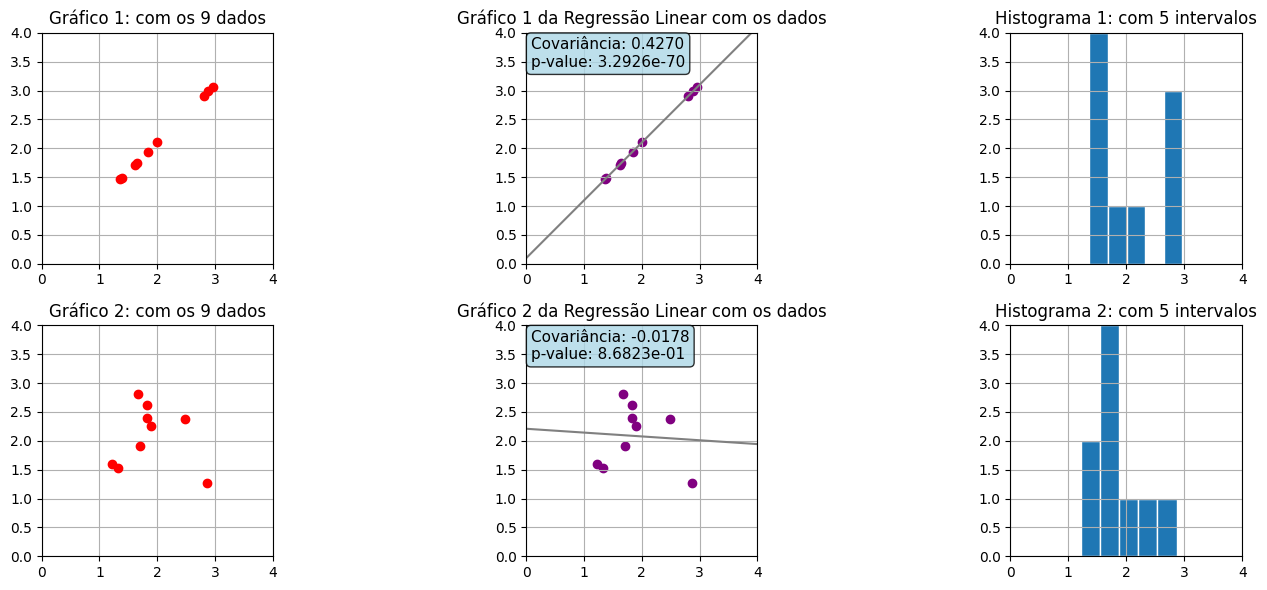

In [71]:
fig, axs= plt.subplots(2, 3, figsize=(16,6))

graph1 = axs[0,0]
graph2 = axs[0,1]
graph3 = axs[0,2]

graph4 = axs[1,0]
graph5 = axs[1,1]
graph6 = axs[1,2]


# Gráfico 1, plotando apenas os 9 pontos
graph1.plot(x1, y1, 'o', color='red')
graph1.set_title('Gráfico 1: com os 9 dados')
graph1.grid(True)
graph1.set_aspect('equal', adjustable='box')
graph1.set_xlim(0,4)
graph1.set_ylim(0,4)

# Gráfico 2, exibindo os 9 valores sob a reta e a reta da Regressão Linear 1
graph2.scatter(x1, y1, color='purple')
graph2.plot(linha_X1, linha_Y1, color='grey')
graph2.set_title('Gráfico 1 da Regressão Linear com os dados')
graph2.grid(True)
graph2.set_aspect('equal', adjustable='box')
graph2.set_xlim(0,4)
graph2.set_ylim(0,4)

info_text1 = (f"Covariância: {covariancia_1:.4f}\n" f"p-value: {pvalue1:.4e}")
graph2.text( 0.02, 0.98, info_text1, transform=graph2.transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Gráfico 3, mostrando o agrupamento dos 9 valores num bin = 5
graph3.hist(x1, bins=5, edgecolor='white')
graph3.set_title('Histograma 1: com 5 intervalos')
graph3.set_xlim(0,4)
graph3.set_ylim(0,4)
graph3.grid(True)
graph3.set_aspect(0.995)

# Gráfico 4, mostrando a disposição dos dados no segundo caso
graph4.plot(x2, y2, 'o', color='red')
graph4.set_title('Gráfico 2: com os 9 dados')
graph4.grid(True)
graph4.set_aspect('equal', adjustable='box')
graph4.set_xlim(0,4)
graph4.set_ylim(0,4)

# Gráfico 5, exibindo os 9 valores sob a reta e a reta da Regressão Linear 2
graph5.scatter(x2, y2, color='purple')
graph5.plot(linha_X2, linha_Y2, color='grey')
graph5.set_title('Gráfico 2 da Regressão Linear com os dados')
graph5.grid(True)
graph5.set_aspect('equal', adjustable='box')
graph5.set_xlim(0,4)
graph5.set_ylim(0,4)

info_text2 = (f"Covariância: {covariancia_2:.4f}\n" f"p-value: {pvalue2:.4e}")
graph5.text( 0.02, 0.98, info_text2, transform=graph5.transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Gráfico 6, msotrando o agrupamento dos 9 valores num bin = 5 para o segundo caso
graph6.hist(x2, bins=5, edgecolor='white')
graph6.set_title('Histograma 2: com 5 intervalos')
graph6.set_xlim(0,4)
graph6.set_ylim(0,4)
graph6.grid(True)
graph6.set_aspect(0.995)

plt.tight_layout()
plt.show()

### Análise

Covariância:
- A covariância em ambos gráficos é positiva, o que significa que a relação linear   
entre as variáveis de ambos os gráficos movem-se na mesma direção.

Valor de Probabilidade:

Dada a hipótese nula $H_0$ = '*Se o slope é zero*'
- Para o gráfico 1: p-valor($3.19\cdot 10^{-70}$) muito pequeno rejeita a hipótese nula.
- Para o gráfico 2: p-valor($ 0.69$) é um valor alto, a hipótese não é rejeitada, os dados não mostram evidência contra a hipótese.

## C ) Estimando um Intervalo de Confiança para a Média

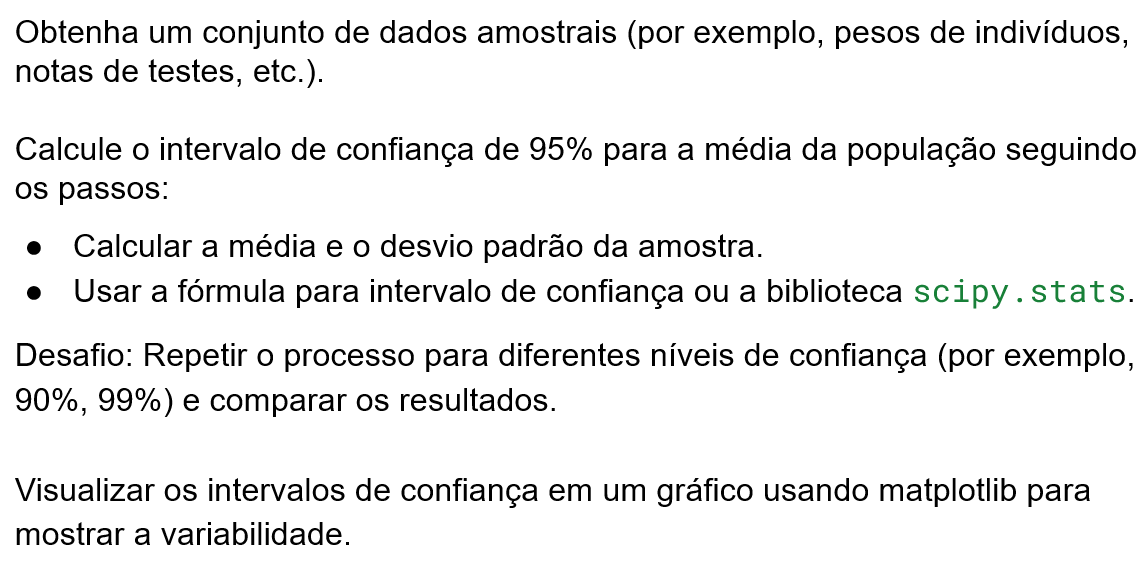

### Dados

In [111]:
dados_pessoas = StringIO("""
Gender,Height,Weight,Index
Male,174,96,4
Male,189,87,2
Female,185,110,4
Female,195,104,3
Male,159,61,3
Male,189,104,3
Male,167,92,5
Male,154,111,5
Male,174,90,3
Female,169,103,4
Male,195,81,2
Female,159,80,4
Female,192,101,3
Male,155,51,2
Male,191,79,2
Female,153,107,5
Female,157,110,5
Male,160,129,5
Male,174,145,5
Male,172,139,5
Male,157,110,5
Female,153,149,5
Female,169,97,4
Male,185,139,5
Female,172,67,2
Female,151,64,3
Male,190,95,3
Male,187,62,1
Female,163,159,5
Male,179,152,5
Male,153,121,5
Male,178,52,1
Female,195,65,1
Female,160,131,5
Male,198,109,3
Male,147,142,5
Male,154,112,5
Female,178,65,2
Male,195,153,5
Female,167,79,3
Male,183,131,4
Female,164,142,5
Male,167,64,2
Female,151,55,2
Female,147,107,5
Female,155,115,5
Female,152,108,4
Female,142,86,5
Male,146,85,4
Female,182,115,4
Male,173,111,4
Female,160,109,5
Male,187,80,2
Male,198,136,4
Female,179,150,5
Female,164,59,2
Female,146,147,5
Female,198,50,0
Female,170,53,1
Male,152,98,5
Female,150,153,5
Female,184,121,4
Female,141,136,5
Male,163,95,5
Male,173,131,5
Male,182,73,2
Male,143,149,5
Male,192,146,5
Male,178,138,5
Female,157,60,2
Male,184,83,2
Male,197,88,2
Female,160,51,2
Male,184,153,5
Male,190,50,0
Male,174,90,3 """)

In [112]:
df = pd.read_csv(dados_pessoas)

df.T

,0,1,2,3,4,5,6,7,8,9,...,66,67,68,69,70,71,72,73,74,75
Gender,Male,Male,Female,Female,Male,Male,Male,Male,Male,Female,...,Male,Male,Male,Female,Male,Male,Female,Male,Male,Male
Height,174,189,185,195,159,189,167,154,174,169,...,143,192,178,157,184,197,160,184,190,174
Weight,96,87,110,104,61,104,92,111,90,103,...,149,146,138,60,83,88,51,153,50,90
Index,4,2,4,3,3,3,5,5,3,4,...,5,5,5,2,2,2,2,5,0,3


### Z-Score

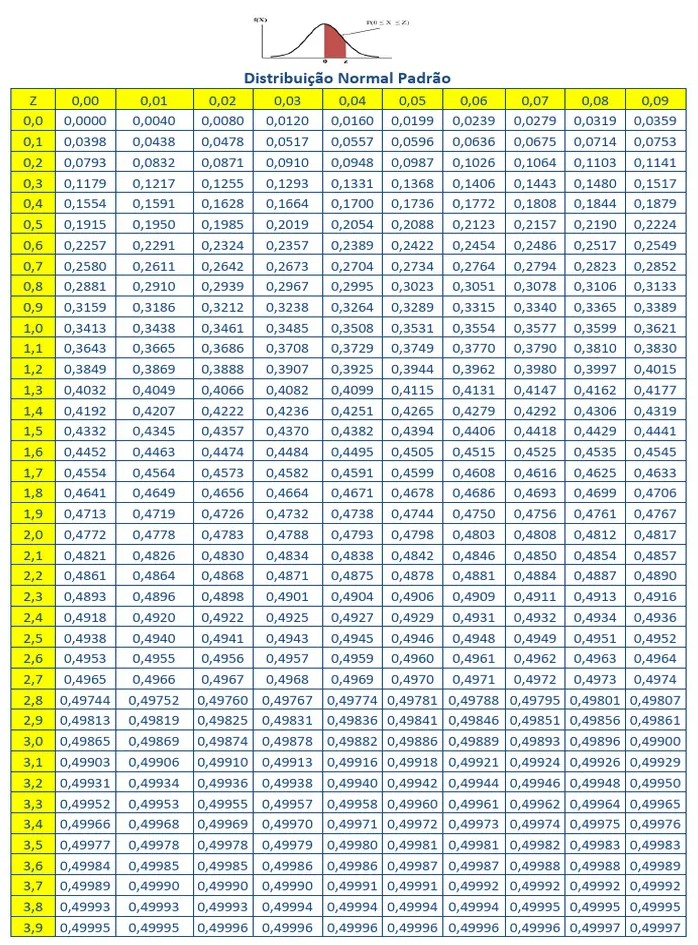

- O valor para o $Z_c$ com a confiança em 95% é obtido da seguinte forma:  
 $0.95 \div 2 = 0.4750$, na tabela este valor corresponde a $1.96$.

- O valor para $Z_c$ com a confiança em 90% é obtido da seguinte forma:  
$0.90 \div 2 = 0.4500$, porém na tabela este valor não existe, mas tem os valores $0.44950$ que dá o valor de $Z_1 = 1.64$  
e o outro é $0.45053$ que dá o valor $Z_2 = 1.65$, entre esses valores se faz uma média que é $Z_m = 1.645$, este será o valor usado.

- O valor para $Z_c$ com confiança em 99% é obtido da seguinte forma:  
$0.99 \div 2 = 0.495$, não existe esse valor na tabela, se recorre a aproximação para encontrar o valor, usando os valores tirados da     tabela, para $0.4949$ o $Z_1 = 2.57$ e para $0.4951$ $Z_2 = 2.58$, se faz a média que resulta em $Z_m = 2.575$, este será o valor usado.  

### Código

In [104]:
media_altura = df["Height"].mean()
variancia = df["Height"].var()
desvio_padrao = df["Height"].std()
amostra_n = len(df)

In [105]:
# Função para calcula o Intervalo de Confiança:
# Intervalo de Confiaça Superior e Intervalo de Confiaça Inferior
def intervalo_confianca_c1(Zcritc, desvio, media, tamanho, decision):
    margem_erro = Zcritc * (desvio/ math.sqrt(tamanho))
    intervalo_Superior = media + margem_erro
    intervalo_Inferior = media - margem_erro
    if decision == 1:
        print(f"Intervalo de Confiança = ({intervalo_Inferior}, {intervalo_Superior})\nMargem de Erro = {(margem_erro):.3f}\n")
    else:
        return media, intervalo_Inferior, intervalo_Superior, f'{(margem_erro):.3f}'

Dada uma base dados amostrais de tamanho $76$ obtém-se os seguintes valores para as estatísticas:

In [106]:
df = pd.DataFrame({ "Estatísticas": [ "Número de Amostras", "Média das Amostras", "Variância", "Desvio Padrão" ], "Valores": [ amostra_n, media_altura, round(variancia, 3), round(desvio_padrao, 3) ]})
df.index = ["", "", "", ""]
df

,Estatísticas,Valores
,Número de Amostras,76.000000
,Média das Amostras,170.552632
,Variância,273.557000
,Desvio Padrão,16.540000


O cálculo dos intervalos de confiança gera os seguintes valores:

In [107]:
intervalos = []
# 90% de confiança
intervalos.append(intervalo_confianca_c1(1.645, desvio_padrao, media_altura, amostra_n, 0))

# 95% de confiança
intervalos.append(intervalo_confianca_c1(1.96,  desvio_padrao, media_altura, amostra_n, 0))

# 99% de confiança
intervalos.append(intervalo_confianca_c1(2.575, desvio_padrao, media_altura, amostra_n, 0))

df = pd.DataFrame( intervalos, columns=["Média", "Limite Inferior", "Limite Superior","Margem de Erro"])
df.index = ["90%", "95%", "99%"]
df

,Média,Limite Inferior,Limite Superior,Margem de Erro
90%,170.552632,167.431708,173.673555,3.121
95%,170.552632,166.834084,174.271179,3.719
99%,170.552632,165.667295,175.437968,4.885


### Gráfico

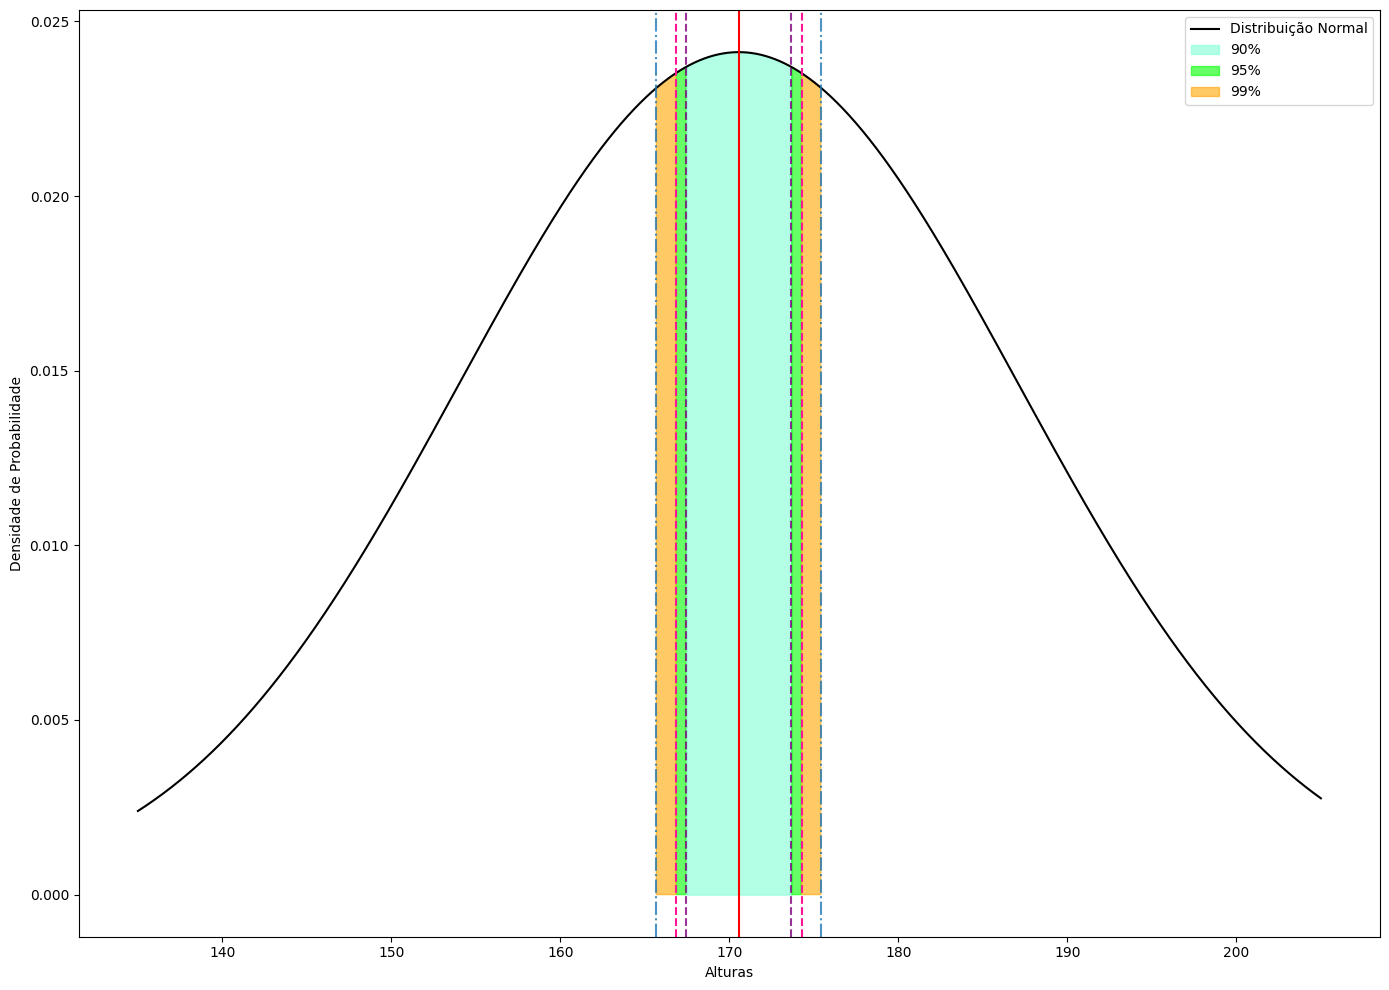

In [108]:
intervalo_inferior1 = intervalo_confianca_c1(1.645, desvio_padrao, media_altura, amostra_n, 0)[1]
intervalo_superior1 = intervalo_confianca_c1(1.645, desvio_padrao, media_altura, amostra_n, 0)[2]

intervalo_inferior2 = intervalo_confianca_c1(1.960, desvio_padrao, media_altura, amostra_n, 0)[1]
intervalo_superior2 = intervalo_confianca_c1(1.960, desvio_padrao, media_altura, amostra_n, 0)[2]

intervalo_inferior3 = intervalo_confianca_c1(2.575, desvio_padrao, media_altura, amostra_n, 0)[1]
intervalo_superior3 = intervalo_confianca_c1(2.575, desvio_padrao, media_altura, amostra_n, 0)[2]

intervalo_x = np.linspace(135, 205, 2000)
p = norm.pdf(intervalo_x, loc=media_altura, scale=desvio_padrao)
plt.figure(figsize=(14, 10))

# Curva total
plt.plot(intervalo_x, p, color='black', label='Distribuição Normal')

# 90%
plt.fill_between( intervalo_x, p, where=(intervalo_x >= intervalo_inferior1) & (intervalo_x <= intervalo_superior1), alpha=0.6, label='90%', color='aquamarine' )

# 95%
plt.fill_between( intervalo_x, p, where=((intervalo_x >= intervalo_inferior2) & (intervalo_x <= intervalo_superior2)) & ~((intervalo_x >= intervalo_inferior1) & (intervalo_x <= intervalo_superior1)), alpha=0.6, label='95%', color='lime' )

# 99%
plt.fill_between( intervalo_x, p, where=((intervalo_x >= intervalo_inferior3) & (intervalo_x <= intervalo_superior3)) & ~((intervalo_x >= intervalo_inferior2) & (intervalo_x <= intervalo_superior2)), alpha=0.6, label='99%', color='orange' )

# Linhas verticais
plt.axvline(media_altura, linestyle='-', alpha=1, color='red')

plt.axvline(intervalo_inferior1, linestyle='--', alpha=0.8, color='purple')
plt.axvline(intervalo_superior1, linestyle='--', alpha=0.8, color='purple')

plt.axvline(intervalo_inferior2, linestyle='--', alpha=1, color='deeppink')
plt.axvline(intervalo_superior2, linestyle='--', alpha=1, color='deeppink')

plt.axvline(intervalo_inferior3, linestyle='-.', alpha=0.8)
plt.axvline(intervalo_superior3, linestyle='-.', alpha=0.8)

plt.xlabel('Alturas')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.tight_layout()
plt.show()

## D ) P-Valor em um Teste de Hipótese


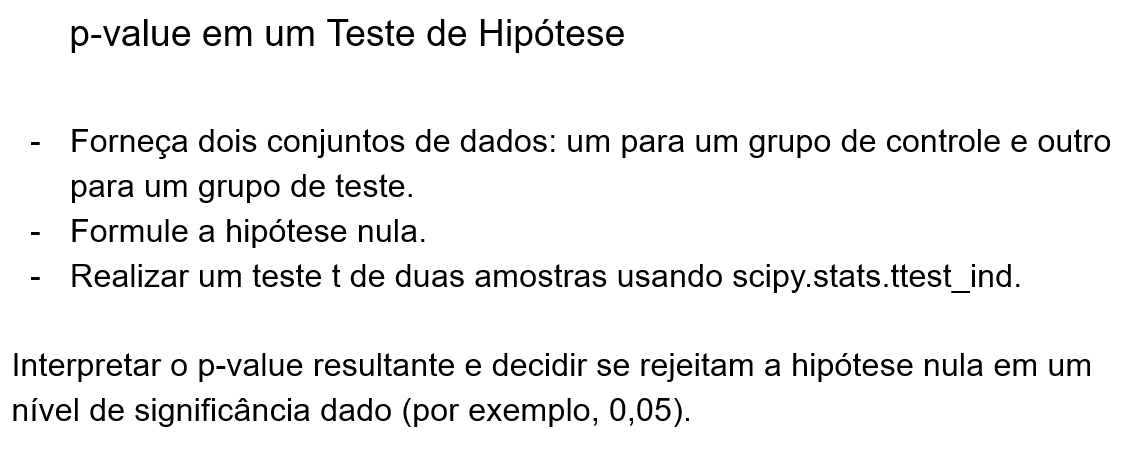

Utilizando a mesma base de dados da questão anterior, mas desta vez utilizando a distinção de gênero.  
O grupo de Controle será a amostra masculina, enquanto a amostra feminina será o grupo de teste.

### Código

In [117]:
masc = df.loc[df["Gender"] == "Male", "Height"].tolist()
fem = df.loc[df["Gender"] == "Female", "Height"].tolist()

print(f" Tamanho da Amostra de Controle (Altura de Homens): {len(masc)}\n Tamanho da Amostra de Teste (Altura de Mulheres): {len(fem)}")

 Tamanho da Amostra de Controle (Altura de Homens): 42
 Tamanho da Amostra de Teste (Altura de Mulheres): 34


Se nota que há uma diferença entre o tamanho das amostras **(Isso influênciará nos procedimentos posteriores)**.  
Será usado o T-teste de Welch, que tem a seguinte fórmula:  
$$t = \frac{x_1 + x_2}{\sqrt{ \frac{v_1}{n_1} + \frac{v_2}{n_2}}}$$

- $x_1$ e $x_2$ são as médias.
- $v_1$ e $v_2$ são as variâncias
- $n_1$ e $n_2$ são os tamanhos das amostras.  

Ele será usado justamente por causa dessa diferença nas amostras.

In [119]:
media_masculina = sum(masc) / len(masc)
media_feminina = sum(fem) / len(fem)

# alteração do csv(Linha 14, de 140 para 160)

df = pd.DataFrame({ "N° de Amostras": [len(masc), len(fem)], "Média Amostral": [media_masculina, media_feminina]})
df.index = ["Masculino", "Feminino"]
df

,N° de Amostras,Média Amostral
Masculino,42,174.809524
Feminino,34,165.294118


### Definindo as Hipóteses

- Formulação da Hipótese Nula: $H_0 =$ *"A média de altura das mulheres é igual a dos homens"*  
Para toda Hipótese Nula tem de haver uma Hipótese Alternativa.
- Formulação da Hipótese Alternativa: $H_1 =$ *"A média de altura das mulheres é diferente da dos homens"*

### Uso da Função `stats.ttest_ind`
- Os seus dois primeiros parâmetros são as duas amostras.
- Diz respeito a dimensão dos dados (nesse caso não será usado).
- O quarto parâmetro fala sobre lidar com variâncias ou tamanhos de amostra desiguais entre as amostras.

In [121]:
t_stat, p_value = stats.ttest_ind(masc, fem, axis=0, equal_var=False, alternative='two-sided')
print(t_stat, p_value)

nivel_significancia = 0.05

if(p_value < nivel_significancia):
    print(f"É correto afirmar, que há diferença entre a média de altura entre homens e mulheres, logo H₀ é rejeitado.")

2.5879142139996025 0.011706280396804105
É correto afirmar, que há diferença entre a média de altura entre homens e mulheres, logo H₀ é rejeitado.


### Análise
É possível perceber que o valor de probabilidade foi de aproximadamente $p_v = 0.01$, ao passo que o nível de significância é $ns=0.05$.

Dados estes valores, como o valor de probabilidade foi menor que o nível de significância, então a Hipótese Nula é rejeitada.

## E ) Nível de Significância (Slide)

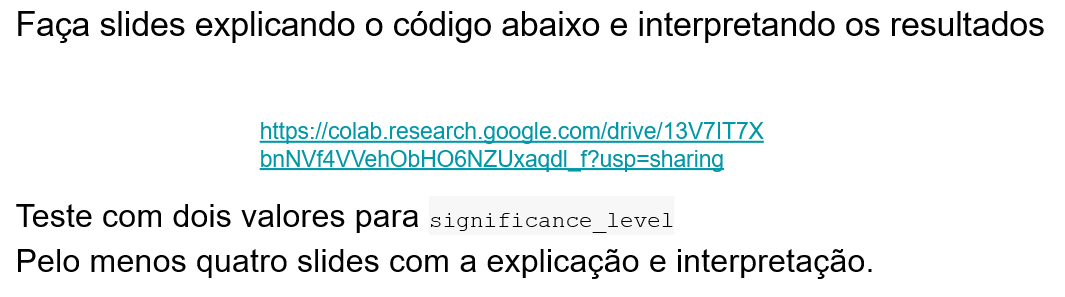

### LINK
[LINK PARA O SLIDE SOBRE NÍVEL DE SIGNIFICÂNCIA](https://drive.google.com/file/d/182eQaJdnX1oMnEDqz-58Ww12cct8-GLi/view?usp=sharing)

## F ) Intervalos de Confiança (Reproduzir Slide)

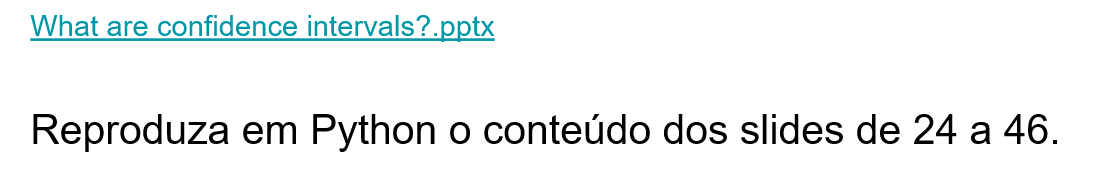

Dada uma amostra de dados sobre frequência de batimentos cardíacos, se tem o objetivo de descobrir o intervalo de confiança e o intervalo de proporção de população.

Mas sabe-se que o número de amostras é $n=50$, além do mais a formula para o Intervalo de Confiança é:

$$ x ± t \cdot (\frac{s}{\sqrt n}) $$

E o intervalo de confiança da população é:
$$
\hat{p} \pm z \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$

In [122]:
# Dados
bpm = [70.0, 81.8, 71.0, 80.8, 72.0, 79.8, 73.0, 78.8, 74.0, 77.8, 75.0, 76.8, 76.0, 75.8, 77.0, 74.8, 78.0, 73.8, 79.0, 72.8, 80.0, 71.8, 69.0, 82.8, 68.0, 83.8, 74.5, 77.3, 75.2, 76.6, 73.5, 78.3, 72.4, 79.4, 71.6, 80.2, 70.8, 81.0, 69.7, 82.1, 74.9, 76.9, 75.4, 76.4, 73.9, 77.9, 72.9, 78.9, 71.9, 79.9]

batimentos_categorico = [1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]

def categorico(listaBinaria):
    contador = 0
    for i in range(len(listaBinaria)):
        if listaBinaria[i] == 1:
            contador += 1
    return contador

media_bpm = sum(bpm) / len(bpm)
proporcao_categorica = categorico(batimentos_categorico) / len(batimentos_categorico) # É a média d

variancia = (sum( ((bpm[i] - media_bpm)**2) for i in range(len(bpm)) )) / (len(bpm)-1)
desvio_padrao_bpm = math.sqrt(variancia)

In [123]:
# Função para calcula o Intervalo de Confiança:
# Intervalo de Confiaça Superior e Intervalo de Confiaça Inferior
def intervalo_confianca(Zcritc, desvio, media, tamanho):
    margem_erro = Zcritc * (desvio/ math.sqrt(tamanho - 1))
    intervalo_Superior = media + margem_erro
    intervalo_Inferior = media - margem_erro
    return media, intervalo_Inferior, intervalo_Superior, f'{(margem_erro):.3f}'

def intervalo_confianca_populacional(Zcrit, proporcao, tamanho):
    erro_padrao = math.sqrt((proporcao * (1-proporcao))/tamanho)
    intervalo_inferior = proporcao - Zcrit * erro_padrao
    intervalo_superior = proporcao + Zcrit * erro_padrao
    return intervalo_inferior, intervalo_superior, erro_padrao, proporcao

print(intervalo_confianca_populacional(1.96, proporcao_categorica, len(batimentos_categorico)))
# Obs: Os valores podem não estar de acordo com o do slide,
# mas é em razão do cálculo no vídeo estar errado.

print(intervalo_confianca(1.96, desvio_padrao_bpm, media_bpm, len(bpm)))

(0.0299252577022837, 0.21007474229771628, 0.04595650117230423, 0.12)
(75.9, 74.82284820011292, 76.9771517998871, '1.077')


## G ) Regressão Linear e o Tema


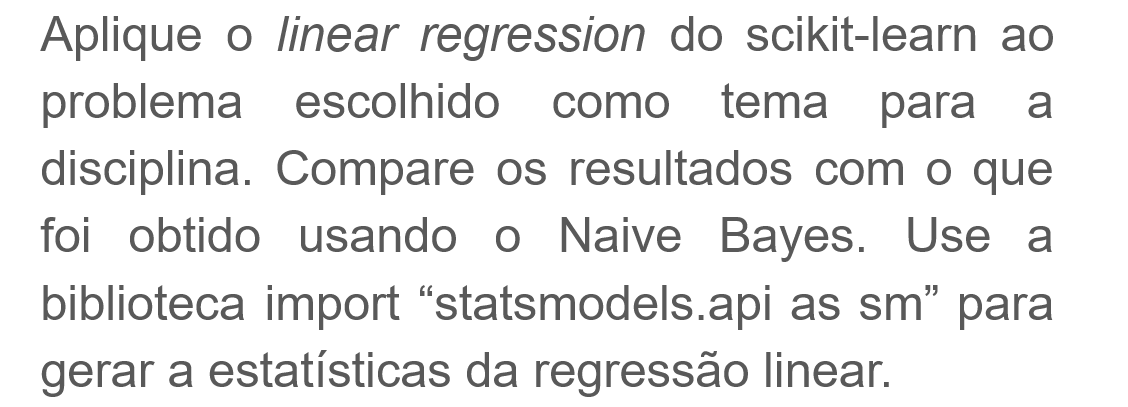

### Código

Regressão Linear com foco na característica (features) "**Compactness**":

**Regressão Linear**

In [19]:
X = df.drop(columns=["ID", "compactness", "seedType"])
y = df["compactness"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: 0.9484080865834656
MSE: 2.3556409071203665e-05


In [21]:
X_sm = sm.add_constant(X)

modelo_sm = sm.OLS(y, X_sm).fit()

print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:            compactness   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     595.8
Date:                Mon, 22 Jun 2026   Prob (F-statistic):          6.32e-126
Time:                        01:54:45   Log-Likelihood:                 796.01
No. Observations:                 210   AIC:                            -1578.
Df Residuals:                     203   BIC:                            -1555.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.2518 

**Naive Bayes**

In [26]:
# Definição da função de Naive Bayes
NB = GaussianNB()

In [29]:
X = df.drop(columns=["ID", "seedType"])
y = df["seedType"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

NB.fit(X_train, y_train)

y_pred = NB.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Acurácia:", acc)

Acurácia: 0.873015873015873


### Análise

Foi aplicada a Regressão Linear utilizando a biblioteca Scikit-Learn para prever a variável **Compactness** a partir das demais características do Seeds Dataset. O modelo apresentou coeficiente de determinação **R² = 0.9484**, indicando que aproximadamente 94,84% da variabilidade da variável pode ser explicada pelas features utilizadas. Além disso, o erro quadrático médio (**MSE = 2,36 × 10⁻⁵**) foi bastante baixo, demonstrando boa capacidade de predição.

A análise realizada com o StatsModels indicou que o modelo é estatisticamente significativo (Prob(F-statistic) = 6,32 × 10⁻¹²⁶). Observou-se também que a variável LengthOfKernel não apresentou significância estatística ($PValor = 0.752$), enquanto as demais contribuíram significativamente para o modelo.

Para comparação, o algoritmo **Gaussian Naive Bayes** foi aplicado ao problema de classificação das sementes, obtendo **acurácia de 87.30%**. Entretanto, a comparação direta entre os dois modelos deve ser feita com atenção, pois eles resolvem problemas muito bem distintos.

Enquanto o Naive Bayes é um algoritmo de classificação utilizado para prever a classe da semente, a Regressão Linear é utilizada para estimar valores contínuos a respeito de características (features). Ainda sim, ambos apresentaram bom desempenho em suas respectivas tarefas: o Naive Bayes na classificação das sementes e a Regressão Linear na predição da variável "Compactness".


## H ) Regressão Linear

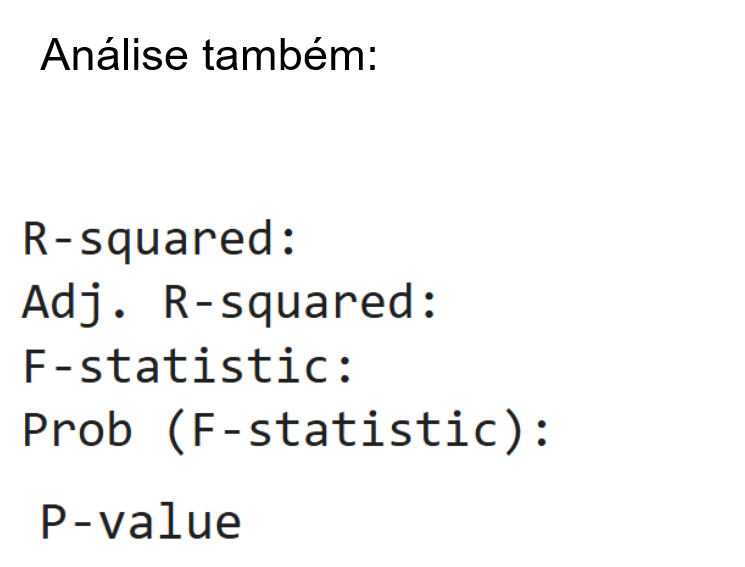

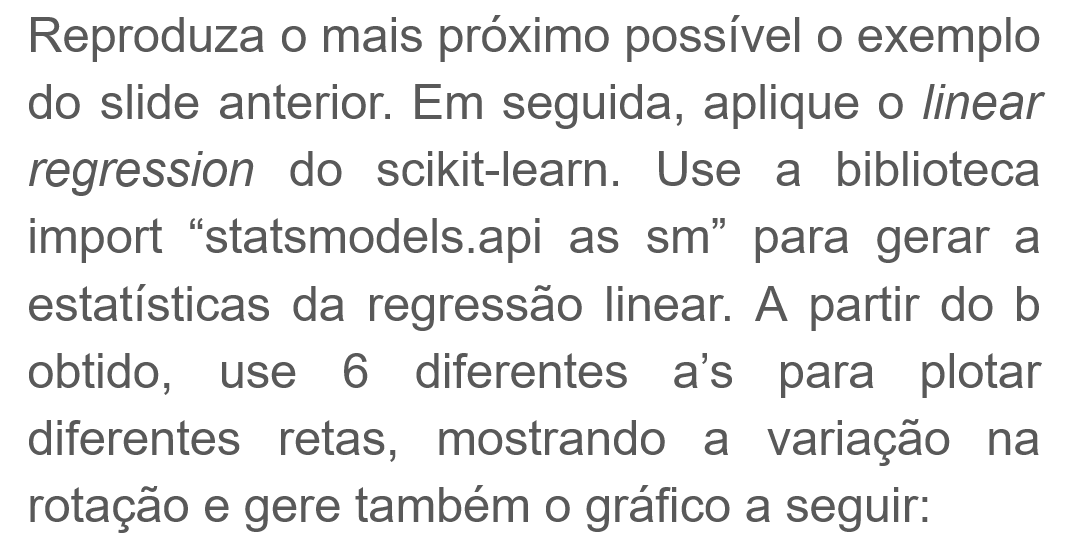

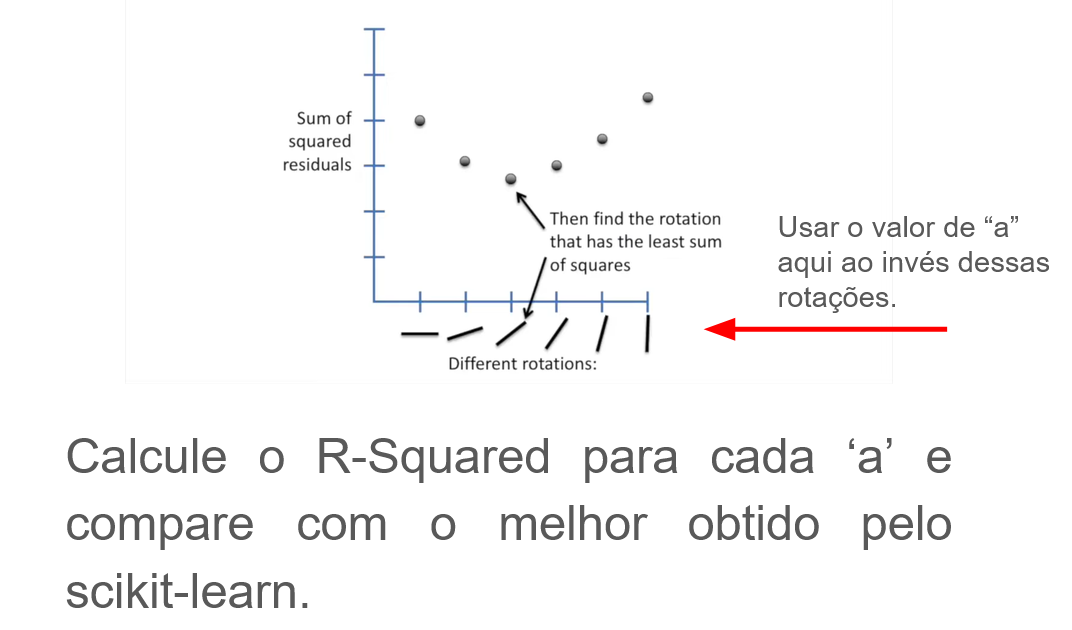

### Código

In [125]:
#x = [0.9, 1.8, 2.4, 3.5, 3.9, 4.4, 5.1, 5.6, 6.3] Dados usados em vídeo
#y = [1.4, 2.6, 1.0, 3.7, 5.5, 3.2, 3.0, 4.9, 6.3] Dados usados em vídeo

x = [0.9, 1.8, 2.4, 3.5, 4.6, 5.1, 5.3, 5.5, 6.3]
y = [1.5, 2.7, 1.1, 3.7, 3.4, 3.2, 5.4, 4.7, 6.3]

In [131]:
# Regressão Linear com o Scikit-Learn

# Conversão de listas para vetores np e resize no x
x = np.array(x)
y = np.array(y)
X = x.reshape(-1, 1)

# Regressão Linear propriamente
modelo_Regressao = LinearRegression()

modelo_Regressao.fit(X,y)

intercept = modelo_Regressao.intercept_     # Coeficiente Linear
slope = modelo_Regressao.coef_[0]           # Coeficiente Angular

reta_x = np.linspace(0, 7, 100)             # Para o gráfico
reta_y = intercept + slope * reta_x         # Reta Y após a Regressão

print(f"O coeficiente Angular(Slope): {slope:.4f}\nO coeficiente Linear(Intercept): {intercept:.4f}")

O coeficiente Angular(Slope): 0.7871
O coeficiente Linear(Intercept): 0.4598


### Gráfico

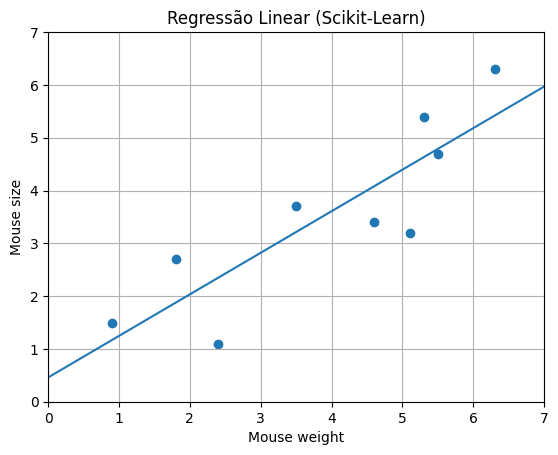

In [127]:
plt.scatter(x, y)
plt.plot(reta_x, reta_y)
plt.grid(True)
plt.xlim(0, 7)
plt.ylim(0, 7)
plt.xlabel("Mouse weight")
plt.ylabel("Mouse size")
plt.title("Regressão Linear (Scikit-Learn)")
plt.show()

In [128]:
# Regressão Linear e Estatísticas com statsmodels

# Ajuste do X
X = sm.add_constant(x)
# Ajuste do modelo
modelo = sm.OLS(y, X).fit()
# Resultados
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     20.10
Date:                Mon, 22 Jun 2026   Prob (F-statistic):            0.00286
Time:                        00:09:57   Log-Likelihood:                -10.979
No. Observations:                   9   AIC:                             25.96
Df Residuals:                       7   BIC:                             26.35
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4598      0.757      0.608      0.5

### Gráfico com Variação da Rotação

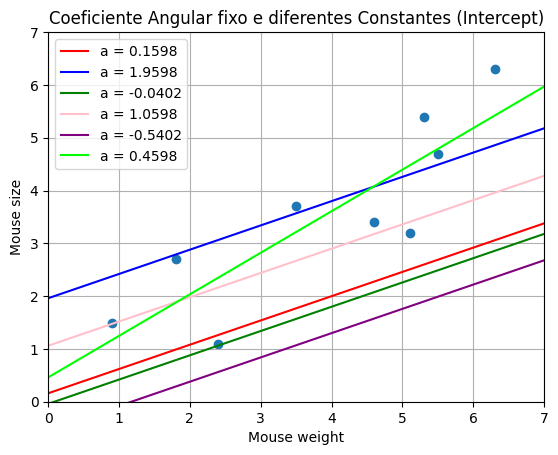

In [129]:
# Pegando valores do Coeficiente Angular e Coeficiente Linear
coeficientes = modelo.params
p_valor = modelo.pvalues
b_intercept = coeficientes[0] # Pegando o Coeficiente Linear(Intercept) que é o que vai mudar

a_slope = coeficientes[1]
intervalos_intercept = [b_intercept - 0.3, b_intercept + 1.5, b_intercept - 0.5, b_intercept + 0.6, b_intercept - 1]

# Gráfico

cores = ['red', 'blue', 'green', 'pink', 'purple', 'brown']

plt.scatter(x, y)

for a, cor in zip(intervalos_intercept, cores):
    y_linha = a + b_intercept * reta_x
    plt.plot(reta_x, y_linha, color=cor, label=f"a = {a:.4f}", alpha = 1)

plt.plot(reta_x, reta_y, color='lime', label=f'a = {b_intercept:.4f}')

plt.xlabel("Mouse weight")
plt.ylabel("Mouse size")
plt.title("Coeficiente Angular fixo e diferentes Constantes (Intercept)")
plt.xlim(0, 7)
plt.ylim(0, 7)
plt.grid(True)
plt.legend()
plt.show()

### Gráfico para Análise

R² (scikit-learn): 0.7416914176974259
[0.56267209 0.00285518]
R² para cada valor de a:

a = 0.460  →  R² = -0.0238
a = 0.160  →  R² = -0.3554
a = 1.960  →  R² = 0.5960
a = -0.040  →  R² = -0.6149
a = 1.060  →  R² = 0.4318
a = -0.540  →  R² = -1.3984


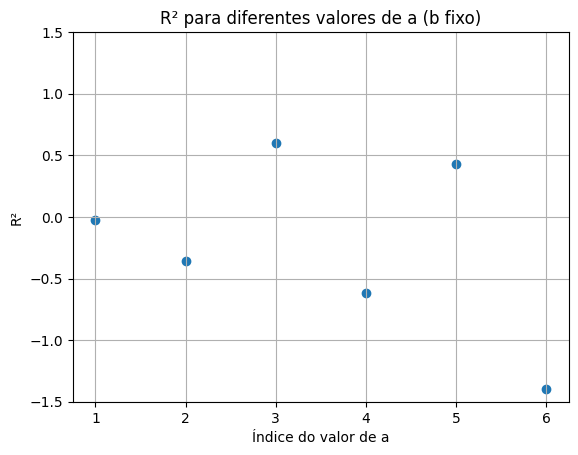

In [133]:
# Recarregar o módulo que está em código para a função funcionar
r2_sklearn = modelo_Regressao.score(X, y)
print("R² (scikit-learn):", r2_sklearn)
# Funcionando com a Regressão do Scikit
def R_SQUARED(y_real, y_pred):
    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
    return 1 - ss_res / ss_tot

intervalos_intercept = [ b_intercept, b_intercept - 0.3, b_intercept + 1.5, b_intercept - 0.5, b_intercept + 0.6, b_intercept - 1]

print(p_valor)
print("R² para cada valor de a:\n")

rotacoes = []

for a in intervalos_intercept:
    y_pred = a + b_intercept * x
    r2 = R_SQUARED(y, y_pred)
    rotacoes.append(r2)
    print(f"a = {a:.3f}  →  R² = {r2:.4f}")

num = [1, 2, 3, 4, 5, 6]

plt.figure()
plt.scatter(range(1, 7), rotacoes)

plt.xlabel("Índice do valor de a")
plt.ylabel("R²")
plt.title("R² para diferentes valores de a (b fixo)")
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.show()

### Análise

Análise:
$R² = 0.742$ → o modelo explica $74.2\%$ da variação dos dados (bom ajuste).

$R²$ ajustado = $0.705$ → ajuste continua bom mesmo penalizando o número de parâmetros.

$F = 20.10$ com $p = 0.00286$ → o modelo é estatisticamente significativo ($p < 0.05$), ou seja, a regressão linear é válida.

p-value do intercepto = $0.563$
→ não significativo ($p > 0.05$).
O termo constante não é estatisticamente diferente de zero.

p-value do slope = $0.00286$
→ significativo ($p < 0.05$).
Existe uma relação linear significativa entre $x$ e $y$.